# LAB 4 IA2
# DCGAN Multimodal — Generación de Espectrogramas de Audio con GTZAN

**Nombre:** Claudia Pereira Cuba  
**Dataset:** (https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification)

**Link github:** https://github.com/pereiracubaclau/Laboratorio4_ia2

**Link Laboratorio:** https://colab.research.google.com/drive/11NoTD2ytOIYI7SACpeFJ2G4Q_WofHi1u?usp=sharing
---

## Descripción del proyecto

En este cuaderno implementamos una **DCGAN** (Deep Convolutional Generative Adversarial Network) aplicada al dataset GTZAN. Los clips de audio se convierten en espectrogramas Mel de 64×64 px y la GAN aprende a sintetizar espectrogramas nuevos.

### Técnicas de estabilización aplicadas

| Técnica | Efecto |
|---|---|
| **TTUR** (Two Time-Scale Update Rule) | LR_G > LR_D → evita *discriminator dominance* |
| **Spectral Normalization (D)** | Gradientes estables en el discriminador |
| **Label Smoothing** | Etiquetas reales en [0.85, 0.95] → D menos confiado |
| **Dropout en D** | Limita la capacidad del discriminador |
| **Non-Saturating Generator Loss** | Gradientes útiles cuando el G falla |
| **BCEWithLogitsLoss** | Más estable numéricamente que BCELoss |
| **Data Augmentation** | Flip horizontal aleatorio → más diversidad |
| **LR Schedulers** | CosineAnnealing → convergencia suave al final |


## Paso 1 — Instalación de dependencias y descarga del dataset

In [1]:
# Instalamos las dependencias necesarias
!pip install librosa --quiet
!pip install kaggle --quiet
!pip install seaborn --quiet

print('Dependencias instaladas.')


Dependencias instaladas.


In [2]:
import os

# Crear carpeta de configuración de Kaggle
!mkdir -p ~/.kaggle

# Guardar el token de acceso
KAGGLE_API_TOKEN = "TU_TOKEN_AQUI"

with open("/root/.kaggle/access_token", "w") as f:
    f.write(KAGGLE_API_TOKEN)

# Asignar permisos correctos
!chmod 600 ~/.kaggle/access_token

print("Token de Kaggle configurado correctamente.")


Token de Kaggle configurado correctamente.


In [3]:
# Descargamos y descomprimimos el dataset GTZAN
import os

print('Descargando dataset GTZAN...')
!kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification --quiet
print('Descomprimiendo...')
!unzip -q gtzan-dataset-music-genre-classification.zip

# Detectamos la ruta raíz con los géneros
DATA_PATH = None
for root, dirs, _ in os.walk('.'):
    if 'blues' in dirs and 'classical' in dirs:
        DATA_PATH = root
        break

assert DATA_PATH is not None, 'No se encontró genres_original. Revisa la estructura del zip.'
print(f' Dataset encontrado en: {DATA_PATH}')


Descargando dataset GTZAN...
Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
License(s): other
Descomprimiendo...
 Dataset encontrado en: ./Data/genres_original


## Paso 2 — Exploración del dataset

Analizamos la composición del dataset: géneros, cantidad de archivos y características de los audios antes de entrenar.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

# ── Listamos géneros y conteos ──────────────────────────────────────────────
generos = sorted([g for g in os.listdir(DATA_PATH)
                  if os.path.isdir(os.path.join(DATA_PATH, g))])
print(f'Total de géneros: {len(generos)}')
print(f'Géneros: {generos}\n')

conteos = {}
total = 0
print('Archivos de audio por género:')
for genre in generos:
    gp = os.path.join(DATA_PATH, genre)
    n  = len([f for f in os.listdir(gp) if f.endswith('.wav')])
    conteos[genre] = n
    total += n
    print(f'  {genre:<12}: {n} archivos')
print(f'\nTotal: {total} archivos')


Total de géneros: 10
Géneros: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Archivos de audio por género:
  blues       : 100 archivos
  classical   : 100 archivos
  country     : 100 archivos
  disco       : 100 archivos
  hiphop      : 100 archivos
  jazz        : 100 archivos
  metal       : 100 archivos
  pop         : 100 archivos
  reggae      : 100 archivos
  rock        : 100 archivos

Total: 1000 archivos


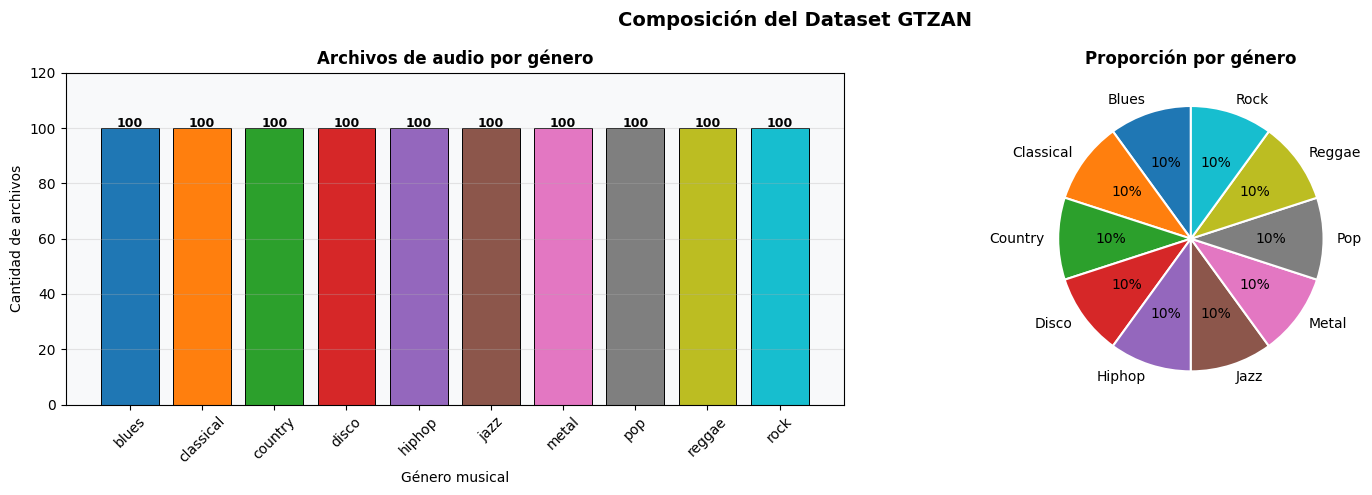

In [5]:
# ── Gráfico de distribución del dataset ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Composición del Dataset GTZAN', fontsize=14, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, len(generos)))

# Barras
bars = axes[0].bar(conteos.keys(), conteos.values(), color=colors,
                   edgecolor='black', linewidth=0.7)
axes[0].set_title('Archivos de audio por género', fontweight='bold')
axes[0].set_ylabel('Cantidad de archivos')
axes[0].set_xlabel('Género musical')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, conteos.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.5, str(val),
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, max(conteos.values()) * 1.2)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_facecolor('#f8f9fa')

# Pie chart
axes[1].pie(conteos.values(), labels=[g.capitalize() for g in conteos.keys()],
            colors=colors, autopct='%1.0f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporción por género', fontweight='bold')

plt.tight_layout()
plt.show()


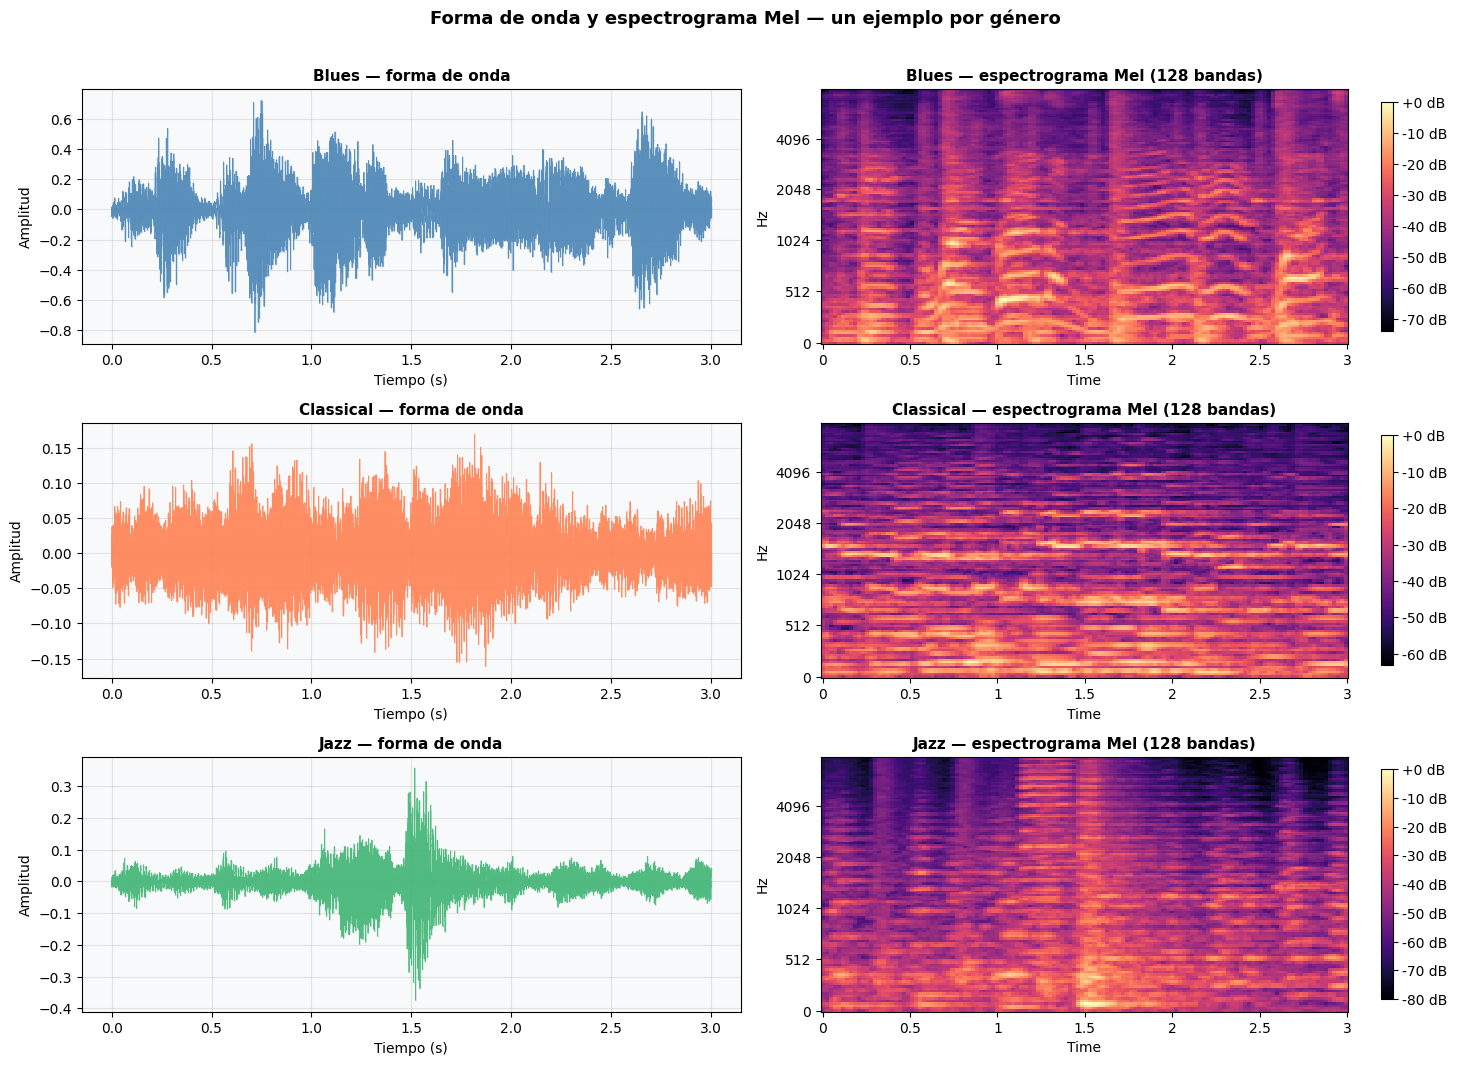

In [6]:
# ── Visualizamos forma de onda + espectrograma de 3 géneros ────────────────
SELECTED_GENRES = ['blues', 'classical', 'jazz']

fig, axes = plt.subplots(len(SELECTED_GENRES), 2, figsize=(15, 3.5 * len(SELECTED_GENRES)))
fig.suptitle('Forma de onda y espectrograma Mel — un ejemplo por género',
             fontsize=13, fontweight='bold', y=1.01)

genre_colors = {'blues': 'steelblue', 'classical': 'coral', 'jazz': 'mediumseagreen'}

for i, genre in enumerate(SELECTED_GENRES):
    gp  = os.path.join(DATA_PATH, genre)
    wav = sorted([f for f in os.listdir(gp) if f.endswith('.wav')])[0]
    y, sr = librosa.load(os.path.join(gp, wav), sr=22050, duration=3.0)
    color = genre_colors[genre]

    # Forma de onda
    axes[i, 0].plot(np.linspace(0, 3, len(y)), y, color=color, linewidth=0.6, alpha=0.85)
    axes[i, 0].fill_between(np.linspace(0, 3, len(y)), y, alpha=0.2, color=color)
    axes[i, 0].set_title(f'{genre.capitalize()} — forma de onda', fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel('Tiempo (s)')
    axes[i, 0].set_ylabel('Amplitud')
    axes[i, 0].grid(alpha=0.3)
    axes[i, 0].set_facecolor('#f8f9fa')

    # Espectrograma Mel
    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img    = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel',
                                      fmax=8000, ax=axes[i, 1], cmap='magma')
    axes[i, 1].set_title(f'{genre.capitalize()} — espectrograma Mel (128 bandas)', fontsize=11, fontweight='bold')
    fig.colorbar(img, ax=axes[i, 1], format='%+2.0f dB', shrink=0.9)

plt.tight_layout()
plt.show()


Duración promedio : 30.0 s
Duración mínima   : 30.0 s
Duración máxima   : 30.5 s
Cumple mínimo 3 s : True


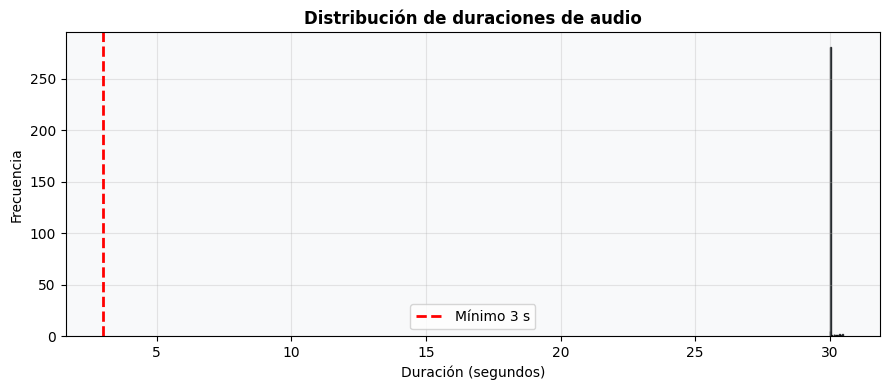

In [7]:
# ── Duración de los audios seleccionados ───────────────────────────────────
durations = []
for genre in SELECTED_GENRES:
    gp = os.path.join(DATA_PATH, genre)
    for wav in os.listdir(gp):
        if wav.endswith('.wav'):
            try:
                dur = librosa.get_duration(path=os.path.join(gp, wav))
                durations.append(dur)
            except:
                pass

print(f'Duración promedio : {np.mean(durations):.1f} s')
print(f'Duración mínima   : {np.min(durations):.1f} s')
print(f'Duración máxima   : {np.max(durations):.1f} s')
print(f'Cumple mínimo 3 s : {np.min(durations) >= 3.0}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(durations, bins=25, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(3.0, color='red', linestyle='--', linewidth=2, label='Mínimo 3 s')
ax.set_title('Distribución de duraciones de audio', fontweight='bold', fontsize=12)
ax.set_xlabel('Duración (segundos)')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.grid(alpha=0.3)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()


## Paso 3 — Preprocesamiento: convertir audios a espectrogramas 64×64

Cada clip de audio se convierte en un espectrograma Mel de **64×64 px** normalizado en **[−1, 1]**.  
Para aumentar el tamaño efectivo del dataset usamos **segmentación por ventanas deslizantes**:
de cada audio de 30 s extraemos múltiples segmentos de 3 s con un paso de 1 s, triplicando el dataset original.


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from sklearn.preprocessing import LabelEncoder
import cv2

# ── Hiperparámetros globales ────────────────────────────────────────────────
IMG_SIZE   = 64
SR         = 22050
DURATION   = 3.0
N_MELS     = 64
N_FFT      = 2048
HOP_LENGTH = 512
WINDOW_STEP = 1.0   # paso de la ventana deslizante (segundos) → más muestras
BATCH_SIZE  = 64    # batch más grande → gradientes más estables
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Dispositivo: {DEVICE}')
if DEVICE == 'cpu':
    print('  AVISO: Se recomienda GPU. En Colab: Entorno → Cambiar tipo de entorno → T4 GPU')
print(f'Tamaño espectrogramas: {IMG_SIZE}×{IMG_SIZE} px')
print(f'Duración por segmento: {DURATION} s')
print(f'Paso ventana deslizante: {WINDOW_STEP} s')
print(f'Batch size: {BATCH_SIZE}')


Dispositivo: cuda
Tamaño espectrogramas: 64×64 px
Duración por segmento: 3.0 s
Paso ventana deslizante: 1.0 s
Batch size: 64


In [9]:
def audio_to_melspec_segments(wav_path, sr=SR, duration=DURATION, step=WINDOW_STEP,
                               n_mels=N_MELS, n_fft=N_FFT,
                               hop_length=HOP_LENGTH, img_size=IMG_SIZE):
    """
    Carga un audio completo y extrae múltiples segmentos con ventana deslizante.
    Devuelve una lista de arrays (img_size, img_size) normalizados en [-1, 1].
    """
    y_full, _ = librosa.load(wav_path, sr=sr)
    target_len = int(sr * duration)
    step_len   = int(sr * step)
    segments   = []

    start = 0
    while start + target_len <= len(y_full):
        y = y_full[start:start + target_len]

        mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                                n_fft=n_fft, hop_length=hop_length, fmax=8000)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_rs = cv2.resize(mel_db, (img_size, img_size))

        vmin, vmax = mel_rs.min(), mel_rs.max()
        if vmax - vmin > 1e-6:
            mel_norm = 2.0 * (mel_rs - vmin) / (vmax - vmin) - 1.0
        else:
            mel_norm = np.zeros_like(mel_rs)

        segments.append(mel_norm.astype(np.float32))
        start += step_len

    return segments


# ── Procesamos el dataset con ventana deslizante ────────────────────────────
print('Generando espectrogramas (ventana deslizante)...')
spectrograms = []
labels_raw   = []
skipped      = 0

for genre in SELECTED_GENRES:
    gp       = os.path.join(DATA_PATH, genre)
    wav_list = sorted([f for f in os.listdir(gp) if f.endswith('.wav')])
    n_segs   = 0
    print(f'  Procesando {genre} ({len(wav_list)} archivos)...', end=' ')
    for wav in wav_list:
        try:
            segs = audio_to_melspec_segments(os.path.join(gp, wav))
            spectrograms.extend(segs)
            labels_raw.extend([genre] * len(segs))
            n_segs += len(segs)
        except Exception:
            skipped += 1
    print(f'→ {n_segs} segmentos')

spectrograms = np.array(spectrograms)
labels_raw   = np.array(labels_raw)

print(f'\nTotal de espectrogramas : {len(spectrograms)}')
print(f'Archivos omitidos       : {skipped}')
print(f'Shape del array         : {spectrograms.shape}')
print(f'Rango de valores        : [{spectrograms.min():.3f}, {spectrograms.max():.3f}]')
print(f'Por género:')
for g in SELECTED_GENRES:
    print(f'  {g}: {np.sum(labels_raw == g)} muestras')


Generando espectrogramas (ventana deslizante)...
  Procesando blues (100 archivos)... → 2800 segmentos
  Procesando classical (100 archivos)... → 2798 segmentos
  Procesando jazz (100 archivos)... → 2772 segmentos

Total de espectrogramas : 8370
Archivos omitidos       : 1
Shape del array         : (8370, 64, 64)
Rango de valores        : [-1.000, 1.000]
Por género:
  blues: 2800 muestras
  classical: 2798 muestras
  jazz: 2772 muestras


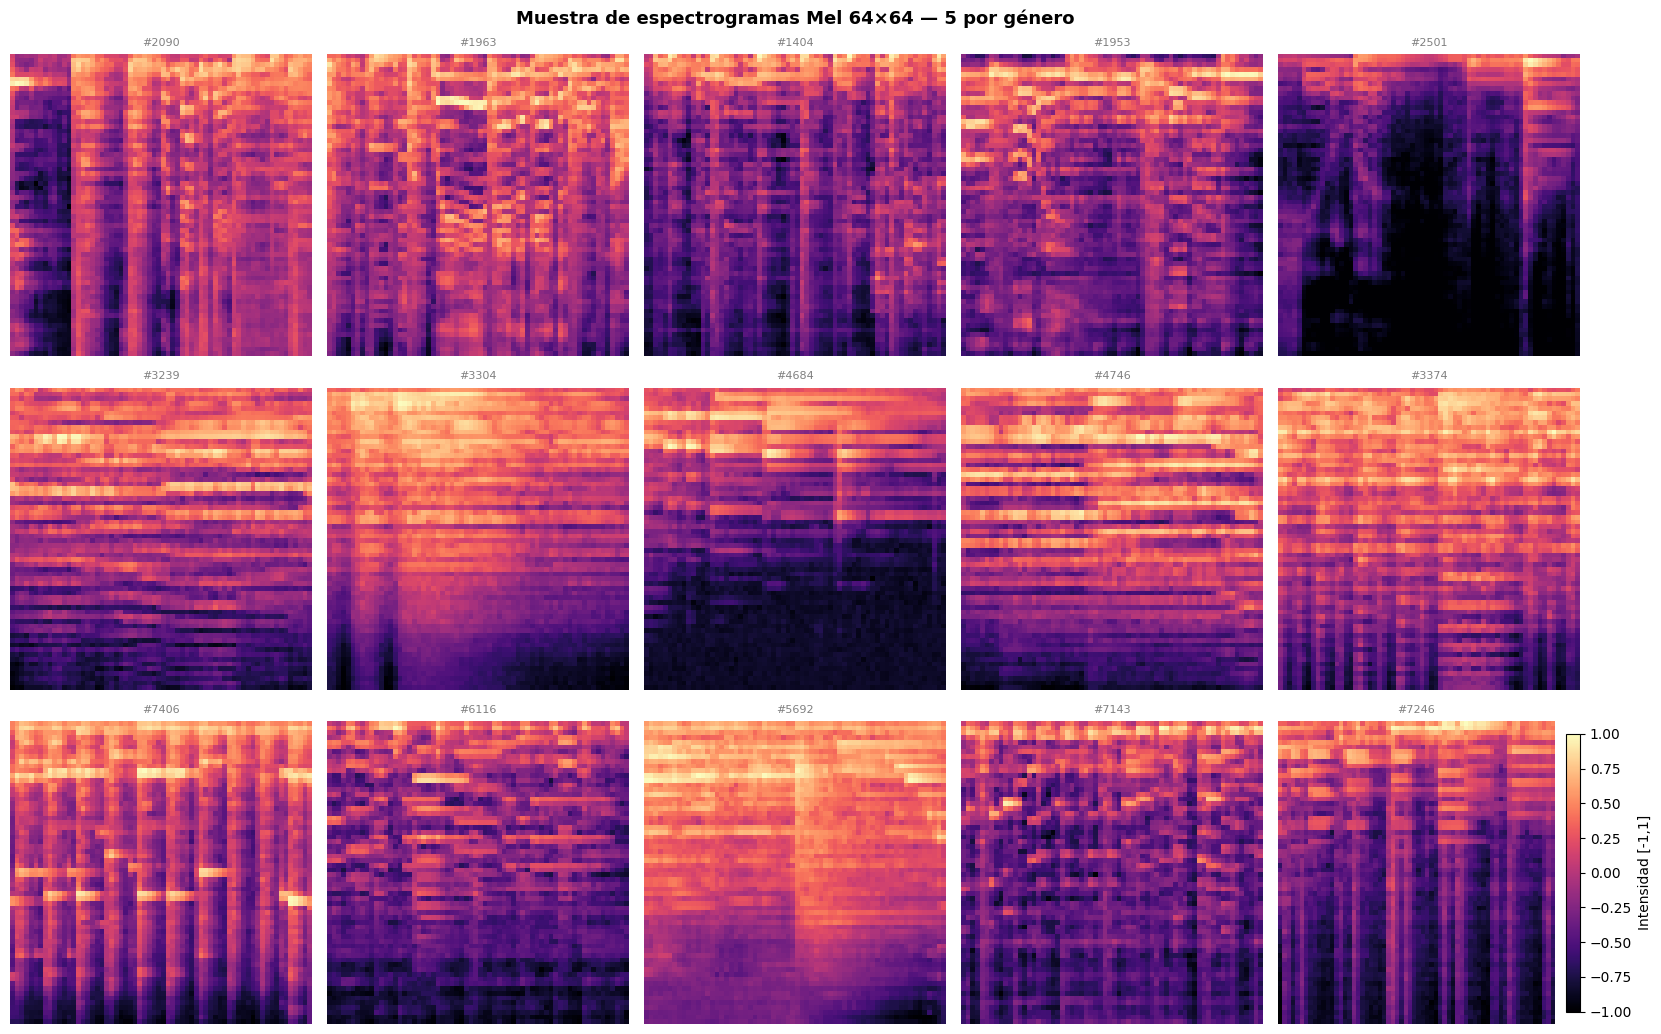

In [10]:
# ── Visualización de 5 espectrogramas por género ───────────────────────────
fig, axes = plt.subplots(len(SELECTED_GENRES), 5, figsize=(16, 3.5 * len(SELECTED_GENRES)))
fig.suptitle('Muestra de espectrogramas Mel 64×64 — 5 por género',
             fontsize=13, fontweight='bold')

gc = {'blues': '#4472C4', 'classical': '#ED7D31', 'jazz': '#70AD47'}
for row, genre in enumerate(SELECTED_GENRES):
    idx    = np.where(labels_raw == genre)[0]
    sample = np.random.choice(idx, 5, replace=False)
    for col, si in enumerate(sample):
        im = axes[row, col].imshow(spectrograms[si], cmap='magma',
                                   aspect='auto', vmin=-1, vmax=1)
        axes[row, col].axis('off')
        axes[row, col].set_title(f'#{si}', fontsize=8, color='gray')
    axes[row, 0].set_ylabel(genre.capitalize(), fontsize=12, fontweight='bold',
                            color=gc[genre])

plt.tight_layout()
plt.colorbar(im, ax=axes[-1, -1], fraction=0.046, pad=0.04, label='Intensidad [-1,1]')
plt.show()


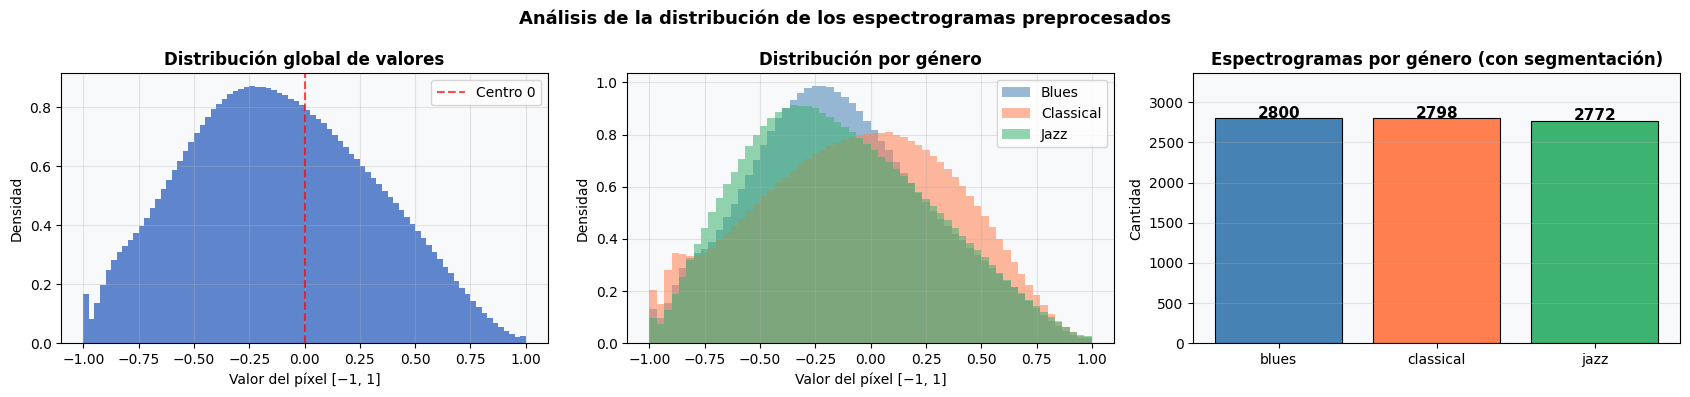

Media global: -0.1134  |  Desv. std: 0.4185
La normalización [-1,1] es correcta para la activación Tanh del generador.


In [11]:
# ── Distribución de intensidades de los espectrogramas ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Análisis de la distribución de los espectrogramas preprocesados',
             fontsize=13, fontweight='bold')

# Histograma global
axes[0].hist(spectrograms.flatten(), bins=80, color='#4472C4',
             edgecolor='none', alpha=0.85, density=True)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7, label='Centro 0')
axes[0].set_title('Distribución global de valores', fontweight='bold')
axes[0].set_xlabel('Valor del píxel [−1, 1]')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_facecolor('#f8f9fa')

# Por género
colors3 = ['steelblue', 'coral', 'mediumseagreen']
for i, genre in enumerate(SELECTED_GENRES):
    idx = np.where(labels_raw == genre)[0]
    axes[1].hist(spectrograms[idx].flatten(), bins=60, alpha=0.55,
                 color=colors3[i], label=genre.capitalize(), density=True)
axes[1].set_title('Distribución por género', fontweight='bold')
axes[1].set_xlabel('Valor del píxel [−1, 1]')
axes[1].set_ylabel('Densidad')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_facecolor('#f8f9fa')

# Conteo por género
conteo = {g: np.sum(labels_raw == g) for g in SELECTED_GENRES}
bars = axes[2].bar(list(conteo.keys()), list(conteo.values()),
                   color=colors3, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, conteo.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 2,
                 str(val), ha='center', fontweight='bold', fontsize=11)
axes[2].set_title('Espectrogramas por género (con segmentación)', fontweight='bold')
axes[2].set_ylabel('Cantidad')
axes[2].set_ylim(0, max(conteo.values()) * 1.2)
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

print(f'Media global: {spectrograms.mean():.4f}  |  Desv. std: {spectrograms.std():.4f}')
print(f'La normalización [-1,1] es correcta para la activación Tanh del generador.')


## Paso 4 — Dataset de PyTorch y DataLoader

Envolvemos los espectrogramas en un `Dataset`. Añadimos **flip horizontal aleatorio** como augmentation:
es semánticamente válido para espectrogramas (la dirección temporal es simétrica) y dobla efectivamente la diversidad de los datos durante el entrenamiento.


In [12]:
class SpectrogramDataset(Dataset):
    """
    Dataset con data augmentation (flip horizontal aleatorio).
    Forma de salida: (1, 64, 64) — canal × alto × ancho.
    """
    def __init__(self, specs, labels, augment=True):
        # (N, 64, 64) → (N, 1, 64, 64)
        self.specs   = torch.tensor(specs[:, np.newaxis, :, :], dtype=torch.float32)
        self.le      = LabelEncoder()
        self.labels  = torch.tensor(self.le.fit_transform(labels), dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.specs)

    def __getitem__(self, idx):
        img = self.specs[idx]
        if self.augment and torch.rand(1).item() > 0.5:
            img = torch.flip(img, dims=[2])   # flip horizontal
        return img, self.labels[idx]


dataset    = SpectrogramDataset(spectrograms, labels_raw, augment=True)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=(DEVICE == 'cuda'),
                        drop_last=True)

imgs, lbls = next(iter(dataloader))
print(f'Shape batch imágenes : {imgs.shape}  → (batch, canal, alto, ancho)')
print(f'Shape etiquetas      : {lbls.shape}')
print(f'Batches por época    : {len(dataloader)}')
print(f'Clases               : {dict(enumerate(dataset.le.classes_))}')
print(f'Augmentation         : flip horizontal con p=0.5')


Shape batch imágenes : torch.Size([64, 1, 64, 64])  → (batch, canal, alto, ancho)
Shape etiquetas      : torch.Size([64])
Batches por época    : 130
Clases               : {0: np.str_('blues'), 1: np.str_('classical'), 2: np.str_('jazz')}
Augmentation         : flip horizontal con p=0.5


## Paso 5 — Arquitectura DCGAN

### Generador
Expande el vector de ruido (100 → 1×1) hasta 64×64 con **5 capas ConvTranspose2d**. BatchNorm + ReLU en cada capa oculta, **Tanh** a la salida.

### Discriminador con Spectral Normalization
La mejora principal respecto a la versión anterior: se añade **Spectral Normalization** (SN) en *todas* las capas convolucionales del discriminador. SN normaliza el peso de cada capa por su mayor valor singular, manteniendo la constante de Lipschitz ≤ 1. Esto estabiliza drásticamente el entrenamiento: el discriminador no puede explotar y bloquear el aprendizaje del generador.

Se combina con **Dropout2d(0.4)** para limitar la capacidad y con **LeakyReLU(0.2)** para evitar gradientes nulos.


In [13]:
from torch.nn.utils import spectral_norm

NZ  = 100   # dimensión del espacio latente
NGF = 64    # filtros base del generador
NDF = 64    # filtros base del discriminador
NC  = 1     # canales (escala de grises)


class Generator(nn.Module):
    """
    Generador DCGAN estándar.
    Entrada : (B, NZ, 1, 1)
    Salida  : (B, 1, 64, 64) con valores en [−1, 1]
    """
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # 1×1 → 4×4
            nn.ConvTranspose2d(NZ, NGF * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(NGF * 8),
            nn.ReLU(True),
            # 4×4 → 8×8
            nn.ConvTranspose2d(NGF * 8, NGF * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF * 4),
            nn.ReLU(True),
            # 8×8 → 16×16
            nn.ConvTranspose2d(NGF * 4, NGF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF * 2),
            nn.ReLU(True),
            # 16×16 → 32×32
            nn.ConvTranspose2d(NGF * 2, NGF, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF),
            nn.ReLU(True),
            # 32×32 → 64×64
            nn.ConvTranspose2d(NGF, NC, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)


class Discriminator(nn.Module):
    """
    Discriminador DCGAN con Spectral Normalization + Dropout.

    Mejoras respecto a la versión anterior:
      - spectral_norm en TODAS las Conv → constante de Lipschitz ≤ 1
      - Dropout2d(0.4) → limita capacidad, evita discriminator dominance
      - Sin Sigmoid (logits) → BCEWithLogitsLoss más estable

    Entrada : (B, 1, 64, 64)
    Salida  : logit escalar por imagen
    """
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # 64×64 → 32×32
            spectral_norm(nn.Conv2d(NC, NDF, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.4),

            # 32×32 → 16×16
            spectral_norm(nn.Conv2d(NDF, NDF * 2, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(NDF * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.4),

            # 16×16 → 8×8
            spectral_norm(nn.Conv2d(NDF * 2, NDF * 4, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(NDF * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.4),

            # 8×8 → 4×4
            spectral_norm(nn.Conv2d(NDF * 4, NDF * 8, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(NDF * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # 4×4 → 1
            spectral_norm(nn.Conv2d(NDF * 8, 1, 4, 1, 0, bias=False))
        )

    def forward(self, x):
        return self.main(x).view(-1)


def weights_init(m):
    """Inicialización DCGAN: Conv N(0, 0.02), BN N(1, 0.02)."""
    cn = m.__class__.__name__
    if 'Conv' in cn:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in cn:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# ── Instanciamos ──────────────────────────────────────────────────────────
netG = Generator().to(DEVICE)
netD = Discriminator().to(DEVICE)
netG.apply(weights_init)
netD.apply(weights_init)

nG = sum(p.numel() for p in netG.parameters())
nD = sum(p.numel() for p in netD.parameters())
print(f'Parámetros del Generador     : {nG:,}')
print(f'Parámetros del Discriminador : {nD:,}')
print(f'Total                        : {nG + nD:,}')

# Verificación de forma
z_test = torch.randn(4, NZ, 1, 1).to(DEVICE)
o_test = netG(z_test)
print(f'\nVerificación: ruido {list(z_test.shape)} → imagen {list(o_test.shape)}')
print(f'Rango de la imagen generada: [{o_test.min().item():.3f}, {o_test.max().item():.3f}]')


Parámetros del Generador     : 3,574,656
Parámetros del Discriminador : 2,763,520
Total                        : 6,338,176

Verificación: ruido [4, 100, 1, 1] → imagen [4, 1, 64, 64]
Rango de la imagen generada: [-0.740, 0.694]


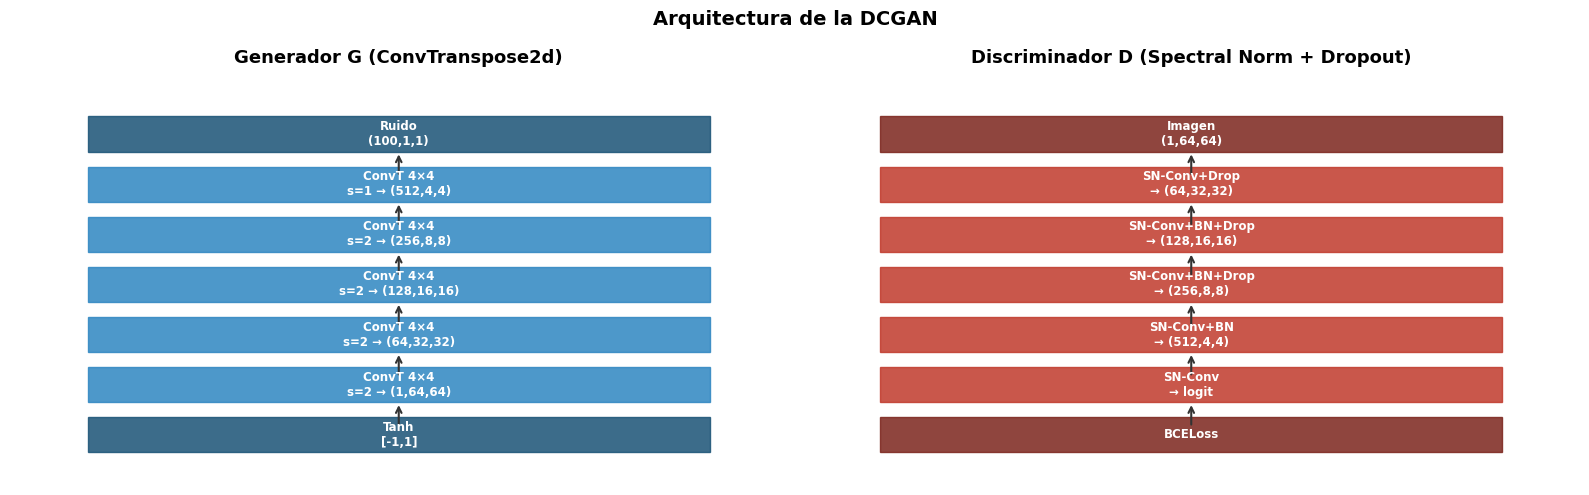

In [14]:
# ── Visualización de la arquitectura ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Arquitectura de la DCGAN', fontsize=14, fontweight='bold')

# Generador
G_layers = [
    ('Ruido\n(100,1,1)', 'input'),
    ('ConvT 4×4\ns=1 → (512,4,4)', 'conv'),
    ('ConvT 4×4\ns=2 → (256,8,8)', 'conv'),
    ('ConvT 4×4\ns=2 → (128,16,16)', 'conv'),
    ('ConvT 4×4\ns=2 → (64,32,32)', 'conv'),
    ('ConvT 4×4\ns=2 → (1,64,64)', 'conv'),
    ('Tanh\n[-1,1]', 'output'),
]

D_layers = [
    ('Imagen\n(1,64,64)', 'input'),
    ('SN-Conv+Drop\n→ (64,32,32)', 'conv'),
    ('SN-Conv+BN+Drop\n→ (128,16,16)', 'conv'),
    ('SN-Conv+BN+Drop\n→ (256,8,8)', 'conv'),
    ('SN-Conv+BN\n→ (512,4,4)', 'conv'),
    ('SN-Conv\n→ logit', 'conv'),
    ('BCELoss', 'output'),
]

def draw_arch(ax, layers, title, color_conv, color_io):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, len(layers) + 1)
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    for i, (name, typ) in enumerate(layers):
        y = len(layers) - i
        c = color_io if typ in ('input', 'output') else color_conv
        rect = plt.Rectangle((1, y - 0.35), 8, 0.7, color=c, alpha=0.85, zorder=2)
        ax.add_patch(rect)
        ax.text(5, y, name, ha='center', va='center', fontsize=8.5, fontweight='bold',
                color='white', zorder=3)
        if i < len(layers) - 1:
            ax.annotate('', xy=(5, y - 0.35), xytext=(5, y - 0.85),
                        arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

draw_arch(axes[0], G_layers, 'Generador G (ConvTranspose2d)',
          color_conv='#2E86C1', color_io='#1A5276')
draw_arch(axes[1], D_layers, 'Discriminador D (Spectral Norm + Dropout)',
          color_conv='#C0392B', color_io='#7B241C')

plt.tight_layout()
plt.show()


## Paso 6 — Entrenamiento de la DCGAN

### Resumen de hiperparámetros optimizados

| Parámetro | Valor | Justificación |
|---|---|---|
| `NUM_EPOCHS` | 200 | Más épocas → mejor convergencia |
| `LR_G` | 0.0002 | Generador aprende más rápido |
| `LR_D` | 0.00005 | TTUR: discriminador más lento |
| `BETA1` | 0.5 | Recomendado para GANs |
| `BATCH_SIZE` | 64 | Gradientes más estables |
| Scheduler | CosineAnnealing | Reduce LR suavemente al final |

El **CosineAnnealing** es clave: en las primeras épocas el LR es alto para explorar el espacio de parámetros; al final decrece suavemente para permitir convergencia fina sin oscilaciones.


In [15]:
# ── Hiperparámetros ─────────────────────────────────────────────────────────
NUM_EPOCHS = 200
LR_G       = 0.0002
LR_D       = 0.00005
BETA1      = 0.5

criterion  = nn.BCEWithLogitsLoss()

optimizerG = torch.optim.Adam(netG.parameters(), lr=LR_G, betas=(BETA1, 0.999))
optimizerD = torch.optim.Adam(netD.parameters(), lr=LR_D, betas=(BETA1, 0.999))

# CosineAnnealingLR: LR decae suavemente hasta 0 al final del entrenamiento
schedulerG = torch.optim.lr_scheduler.CosineAnnealingLR(optimizerG, T_max=NUM_EPOCHS, eta_min=1e-5)
schedulerD = torch.optim.lr_scheduler.CosineAnnealingLR(optimizerD, T_max=NUM_EPOCHS, eta_min=5e-6)

# Ruido fijo para monitorear evolución visual época a época
fixed_noise = torch.randn(16, NZ, 1, 1, device=DEVICE)

# Registros del entrenamiento
G_losses  = []
D_losses  = []
D_x_hist  = []   # prob. discriminador sobre reales
D_Gz_hist = []   # prob. discriminador sobre falsos
LR_G_hist = []   # LR del generador
LR_D_hist = []   # LR del discriminador

# Snapshots visuales del generador cada N épocas
snap_epochs = []
snap_images = []

print('─' * 65)
print('Configuración del entrenamiento:')
print(f'  Épocas         : {NUM_EPOCHS}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  LR Generador   : {LR_G}  (TTUR: más alto)')
print(f'  LR Discrimin.  : {LR_D}  (TTUR: más bajo)')
print(f'  Scheduler      : CosineAnnealing (T_max={NUM_EPOCHS})')
print(f'  Loss           : BCEWithLogitsLoss')
print(f'  Label smoothing: [0.85, 0.95] para reales')
print(f'  Spectral Norm  : Sí (en todas las Conv del D)')
print(f'  Dropout D      : 0.4')
print(f'  Augmentation   : flip horizontal p=0.5')
print(f'  Batches/época  : {len(dataloader)}')
print(f'  Dispositivo    : {DEVICE}')
print('─' * 65)


─────────────────────────────────────────────────────────────────
Configuración del entrenamiento:
  Épocas         : 200
  Batch size     : 64
  LR Generador   : 0.0002  (TTUR: más alto)
  LR Discrimin.  : 5e-05  (TTUR: más bajo)
  Scheduler      : CosineAnnealing (T_max=200)
  Loss           : BCEWithLogitsLoss
  Label smoothing: [0.85, 0.95] para reales
  Spectral Norm  : Sí (en todas las Conv del D)
  Dropout D      : 0.4
  Augmentation   : flip horizontal p=0.5
  Batches/época  : 130
  Dispositivo    : cuda
─────────────────────────────────────────────────────────────────


In [16]:
# ── Bucle de entrenamiento ──────────────────────────────────────────────────
SNAP_EVERY = 20   # guardar snapshot visual cada N épocas

for epoch in range(1, NUM_EPOCHS + 1):
    netG.train()
    netD.train()

    g_sum = d_sum = dx_sum = dg_sum = 0.0
    nb = 0

    for real_imgs, _ in dataloader:
        b         = real_imgs.size(0)
        real_imgs = real_imgs.to(DEVICE)

        # ── Actualizar Discriminador ─────────────────────────────────────
        netD.zero_grad()

        # Reales con label smoothing [0.85, 0.95]
        label_r   = torch.FloatTensor(b).uniform_(0.85, 0.95).to(DEVICE)
        logits_r  = netD(real_imgs)
        loss_Dr   = criterion(logits_r, label_r)
        loss_Dr.backward()
        D_x = torch.sigmoid(logits_r).mean().item()

        # Falsos (etiqueta 0)
        noise      = torch.randn(b, NZ, 1, 1, device=DEVICE)
        fake_imgs  = netG(noise)
        label_f    = torch.zeros(b, device=DEVICE)
        logits_f   = netD(fake_imgs.detach())
        loss_Df    = criterion(logits_f, label_f)
        loss_Df.backward()
        optimizerD.step()

        loss_D = loss_Dr.item() + loss_Df.item()

        # ── Actualizar Generador (non-saturating loss) ───────────────────
        netG.zero_grad()
        label_g   = torch.ones(b, device=DEVICE)    # non-saturating
        logits_g  = netD(fake_imgs)
        loss_G    = criterion(logits_g, label_g)
        loss_G.backward()
        optimizerG.step()

        D_Gz = torch.sigmoid(logits_g).mean().item()

        g_sum  += loss_G.item()
        d_sum  += loss_D
        dx_sum += D_x
        dg_sum += D_Gz
        nb     += 1

    # ── Scheduler step ───────────────────────────────────────────────────
    schedulerG.step()
    schedulerD.step()

    avg_g  = g_sum  / nb
    avg_d  = d_sum  / nb
    avg_dx = dx_sum / nb
    avg_dg = dg_sum / nb
    lr_g   = optimizerG.param_groups[0]['lr']
    lr_d   = optimizerD.param_groups[0]['lr']

    G_losses.append(avg_g)
    D_losses.append(avg_d)
    D_x_hist.append(avg_dx)
    D_Gz_hist.append(avg_dg)
    LR_G_hist.append(lr_g)
    LR_D_hist.append(lr_d)

    # ── Snapshot visual ──────────────────────────────────────────────────
    if epoch % SNAP_EVERY == 0 or epoch == 1 or epoch == NUM_EPOCHS:
        netG.eval()
        with torch.no_grad():
            imgs_snap = netG(fixed_noise).cpu().numpy()
        snap_epochs.append(epoch)
        snap_images.append(imgs_snap)
        netG.train()

    # ── Log de consola ───────────────────────────────────────────────────
    if epoch % 20 == 0 or epoch == 1:
        print(
            f'Época [{epoch:3d}/{NUM_EPOCHS}]  '
            f'G: {avg_g:.4f}  D: {avg_d:.4f}  '
            f'D(x): {avg_dx:.3f}  D(G(z)): {avg_dg:.3f}  '
            f'LR_G: {lr_g:.2e}'
        )

print('─' * 65)
print('Entrenamiento finalizado.')
print(f'  Loss final G     : {G_losses[-1]:.4f}')
print(f'  Loss final D     : {D_losses[-1]:.4f}')
print(f'  D(x) final       : {D_x_hist[-1]:.4f}  (ideal ~0.5)')
print(f'  D(G(z)) final    : {D_Gz_hist[-1]:.4f}  (ideal ~0.5)')


Época [  1/200]  G: 1.5887  D: 1.4375  D(x): 0.481  D(G(z)): 0.239  LR_G: 2.00e-04
Época [ 20/200]  G: 1.1859  D: 1.2894  D(x): 0.493  D(G(z)): 0.324  LR_G: 1.95e-04
Época [ 40/200]  G: 0.9403  D: 1.3528  D(x): 0.466  D(G(z)): 0.400  LR_G: 1.82e-04
Época [ 60/200]  G: 0.9391  D: 1.3304  D(x): 0.470  D(G(z)): 0.399  LR_G: 1.61e-04
Época [ 80/200]  G: 0.9296  D: 1.3068  D(x): 0.477  D(G(z)): 0.404  LR_G: 1.34e-04
Época [100/200]  G: 0.9413  D: 1.2908  D(x): 0.482  D(G(z)): 0.399  LR_G: 1.05e-04
Época [120/200]  G: 0.9247  D: 1.2843  D(x): 0.484  D(G(z)): 0.405  LR_G: 7.56e-05
Época [140/200]  G: 0.9159  D: 1.2605  D(x): 0.490  D(G(z)): 0.408  LR_G: 4.92e-05
Época [160/200]  G: 0.9022  D: 1.2588  D(x): 0.491  D(G(z)): 0.413  LR_G: 2.81e-05
Época [180/200]  G: 0.9372  D: 1.2258  D(x): 0.500  D(G(z)): 0.399  LR_G: 1.46e-05
Época [200/200]  G: 0.9379  D: 1.2183  D(x): 0.503  D(G(z)): 0.399  LR_G: 1.00e-05
─────────────────────────────────────────────────────────────────
Entrenamiento finaliz

## Paso 7 — Análisis completo del entrenamiento

Visualizamos 6 gráficas que cubren todos los aspectos del entrenamiento:
las pérdidas brutas, las pérdidas suavizadas, las probabilidades del discriminador, la diferencia de pérdidas (equilibrio), la evolución del learning rate y la comparación de fases (primeras vs últimas épocas).


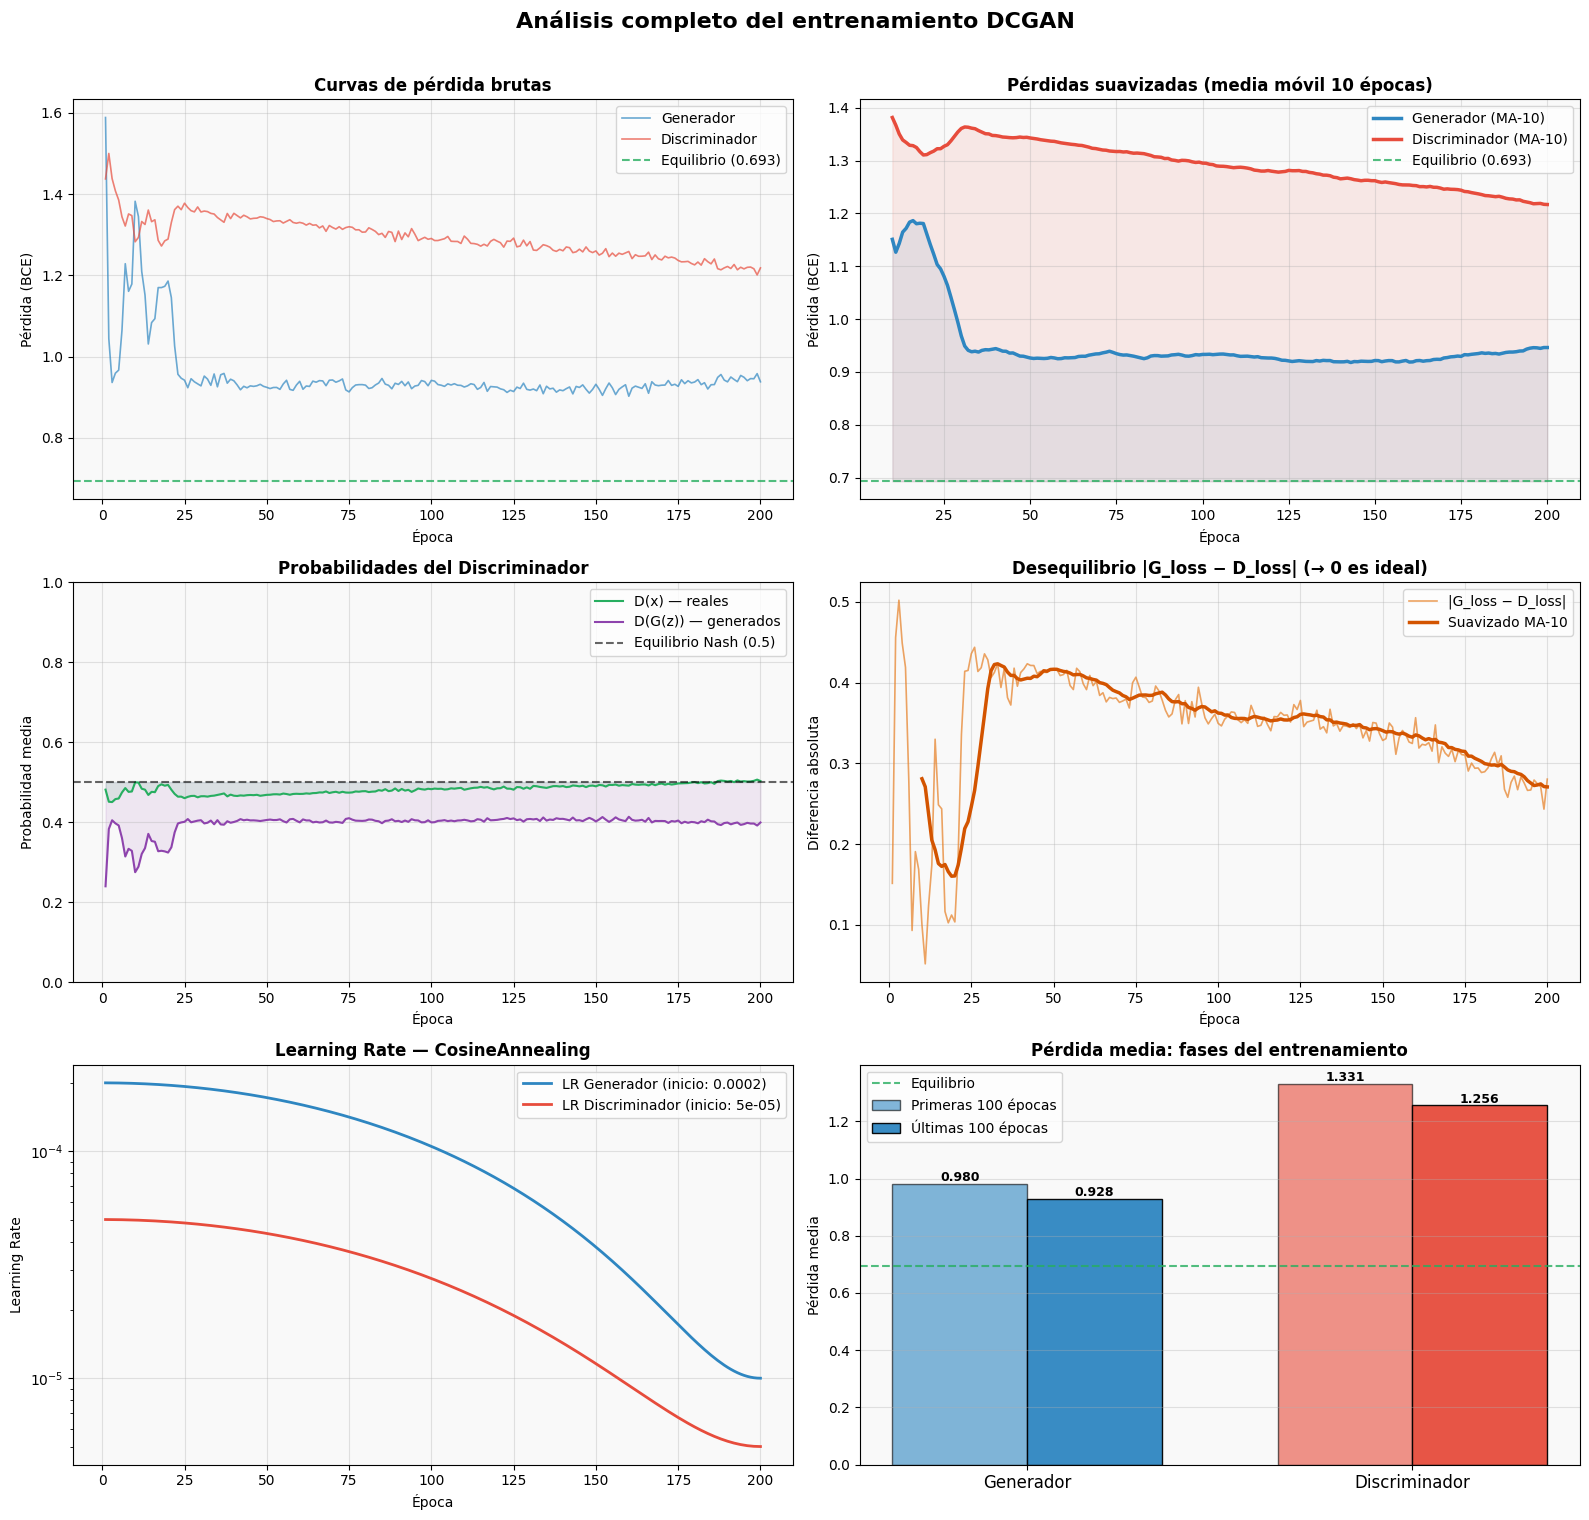

────────────────────────────────────────────────────────────
Loss G final   : 0.9379  (equilibrio ideal: 0.693)
Loss D final   : 1.2183  (equilibrio ideal: 0.693)
D(x) final     : 0.5025  (ideal: ~0.5)
D(G(z)) final  : 0.3989  (ideal: ~0.5)
  Las pérdidas se alejaron del equilibrio — considera más épocas o ajustar LR.


In [17]:
def moving_avg(data, window=10):
    return np.convolve(data, np.ones(window) / window, mode='valid')

epochs_range = np.arange(1, NUM_EPOCHS + 1)
ma_range     = np.arange(10, NUM_EPOCHS + 1)   # para moving avg con window=10

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle('Análisis completo del entrenamiento DCGAN', fontsize=16, fontweight='bold', y=1.01)

# ── 1. Pérdidas brutas ────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(epochs_range, G_losses, color='#2E86C1', linewidth=1.2, alpha=0.7, label='Generador')
ax.plot(epochs_range, D_losses, color='#E74C3C', linewidth=1.2, alpha=0.7, label='Discriminador')
ax.axhline(0.693, color='#27AE60', linestyle='--', linewidth=1.5, alpha=0.8, label='Equilibrio (0.693)')
ax.set_title('Curvas de pérdida brutas', fontweight='bold', fontsize=12)
ax.set_xlabel('Época')
ax.set_ylabel('Pérdida (BCE)')
ax.legend(fontsize=10)
ax.grid(alpha=0.35)
ax.set_facecolor('#f9f9f9')

# ── 2. Pérdidas suavizadas ────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(ma_range, moving_avg(G_losses), color='#2E86C1', linewidth=2.5, label='Generador (MA-10)')
ax.plot(ma_range, moving_avg(D_losses), color='#E74C3C', linewidth=2.5, label='Discriminador (MA-10)')
ax.axhline(0.693, color='#27AE60', linestyle='--', linewidth=1.5, alpha=0.8, label='Equilibrio (0.693)')
ax.fill_between(ma_range, moving_avg(G_losses), 0.693, alpha=0.1, color='#2E86C1')
ax.fill_between(ma_range, moving_avg(D_losses), 0.693, alpha=0.1, color='#E74C3C')
ax.set_title('Pérdidas suavizadas (media móvil 10 épocas)', fontweight='bold', fontsize=12)
ax.set_xlabel('Época')
ax.set_ylabel('Pérdida (BCE)')
ax.legend(fontsize=10)
ax.grid(alpha=0.35)
ax.set_facecolor('#f9f9f9')

# ── 3. Probabilidades D(x) y D(G(z)) ─────────────────────────────────────
ax = axes[1, 0]
ax.plot(epochs_range, D_x_hist,  color='#27AE60', linewidth=1.5, label='D(x) — reales')
ax.plot(epochs_range, D_Gz_hist, color='#8E44AD', linewidth=1.5, label='D(G(z)) — generados')
ax.axhline(0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.6, label='Equilibrio Nash (0.5)')
ax.fill_between(epochs_range, D_x_hist,  0.5, alpha=0.1, color='#27AE60')
ax.fill_between(epochs_range, D_Gz_hist, 0.5, alpha=0.1, color='#8E44AD')
ax.set_title('Probabilidades del Discriminador', fontweight='bold', fontsize=12)
ax.set_xlabel('Época')
ax.set_ylabel('Probabilidad media')
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(alpha=0.35)
ax.set_facecolor('#f9f9f9')

# ── 4. Diferencia |G_loss - D_loss| ──────────────────────────────────────
dif = np.abs(np.array(G_losses) - np.array(D_losses))
ax = axes[1, 1]
ax.plot(epochs_range, dif, color='#E67E22', linewidth=1.2, alpha=0.7, label='|G_loss − D_loss|')
if len(dif) >= 10:
    ax.plot(ma_range, moving_avg(dif), color='#D35400', linewidth=2.5, label='Suavizado MA-10')
ax.set_title('Desequilibrio |G_loss − D_loss| (→ 0 es ideal)', fontweight='bold', fontsize=12)
ax.set_xlabel('Época')
ax.set_ylabel('Diferencia absoluta')
ax.legend(fontsize=10)
ax.grid(alpha=0.35)
ax.set_facecolor('#f9f9f9')

# ── 5. Evolución del Learning Rate (CosineAnnealing) ─────────────────────
ax = axes[2, 0]
ax.plot(epochs_range, LR_G_hist, color='#2E86C1', linewidth=2, label=f'LR Generador (inicio: {LR_G})')
ax.plot(epochs_range, LR_D_hist, color='#E74C3C', linewidth=2, label=f'LR Discriminador (inicio: {LR_D})')
ax.set_title('Learning Rate — CosineAnnealing', fontweight='bold', fontsize=12)
ax.set_xlabel('Época')
ax.set_ylabel('Learning Rate')
ax.legend(fontsize=10)
ax.grid(alpha=0.35)
ax.set_facecolor('#f9f9f9')
ax.set_yscale('log')

# ── 6. Fases: primeras vs últimas épocas ─────────────────────────────────
ax = axes[2, 1]
half = NUM_EPOCHS // 2
early_g = np.mean(G_losses[:half])
late_g  = np.mean(G_losses[half:])
early_d = np.mean(D_losses[:half])
late_d  = np.mean(D_losses[half:])

barw = 0.35
x    = np.array([0, 1])
b1 = ax.bar(x - barw/2, [early_g, early_d], barw, label='Primeras 100 épocas',
            color=['#2E86C1', '#E74C3C'], alpha=0.6, edgecolor='black')
b2 = ax.bar(x + barw/2, [late_g,  late_d],  barw, label='Últimas 100 épocas',
            color=['#2E86C1', '#E74C3C'], alpha=0.95, edgecolor='black')
ax.axhline(0.693, color='#27AE60', linestyle='--', linewidth=1.5, alpha=0.8, label='Equilibrio')
ax.set_xticks(x)
ax.set_xticklabels(['Generador', 'Discriminador'], fontsize=12)
ax.set_title('Pérdida media: fases del entrenamiento', fontweight='bold', fontsize=12)
ax.set_ylabel('Pérdida media')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.35)
ax.set_facecolor('#f9f9f9')
for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('─' * 60)
print(f'Loss G final   : {G_losses[-1]:.4f}  (equilibrio ideal: 0.693)')
print(f'Loss D final   : {D_losses[-1]:.4f}  (equilibrio ideal: 0.693)')
print(f'D(x) final     : {D_x_hist[-1]:.4f}  (ideal: ~0.5)')
print(f'D(G(z)) final  : {D_Gz_hist[-1]:.4f}  (ideal: ~0.5)')
eq = abs(G_losses[-1] - 0.693) < 0.25 and abs(D_losses[-1] - 0.693) < 0.25
if eq:
    print('Ambas pérdidas cercanas al equilibrio Nash (0.693) → entrenamiento estable.')
else:
    print('  Las pérdidas se alejaron del equilibrio — considera más épocas o ajustar LR.')


## Paso 8 — Evolución visual del Generador a lo largo del entrenamiento

Una de las mejores formas de verificar que el entrenamiento fue exitoso es observar cómo evoluciona la calidad de las imágenes generadas época a época. Al principio el generador produce ruido puro; a medida que entrena, las estructuras de los espectrogramas van emergiendo progresivamente.


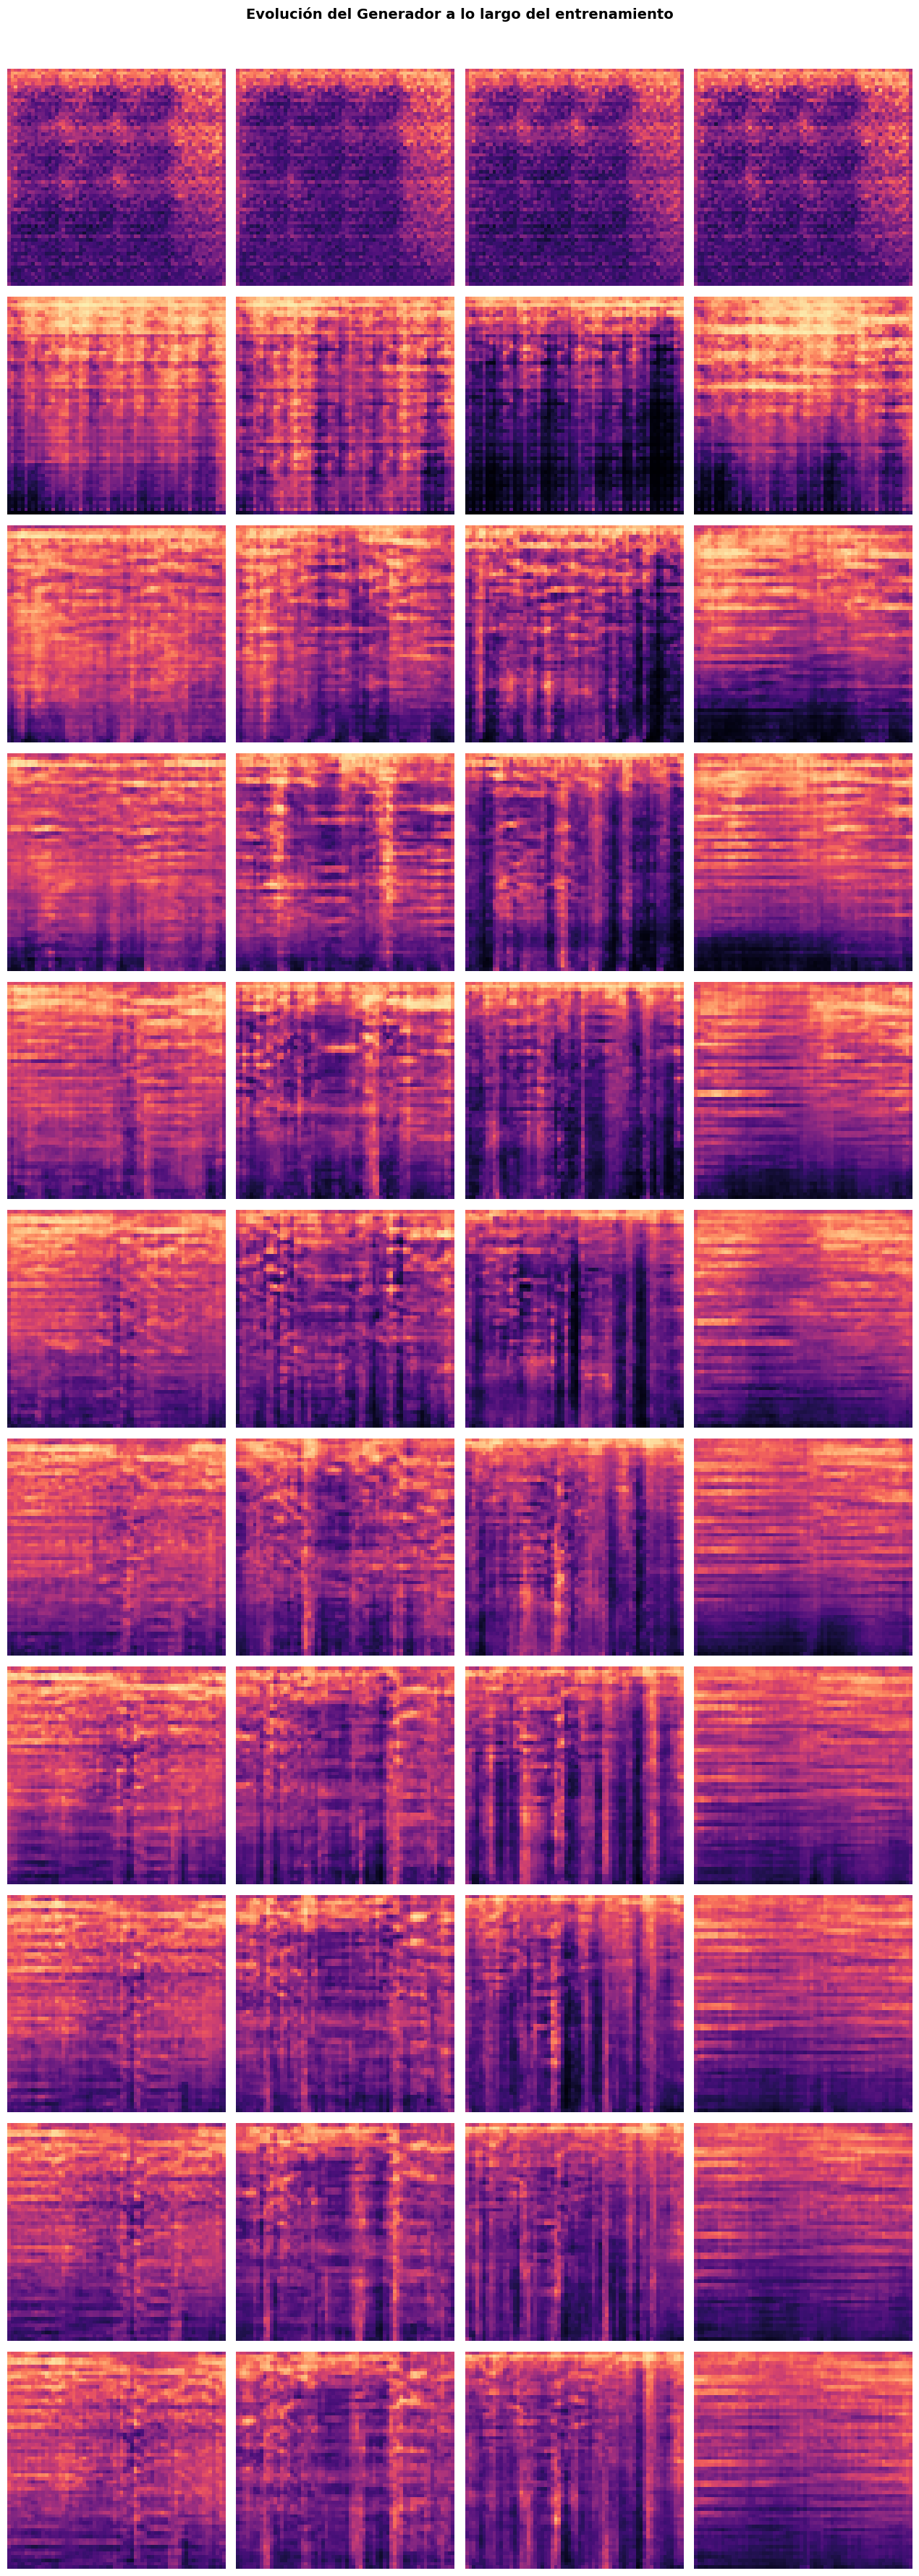

Las imágenes van ganando estructura a medida que el generador aprende la distribución.


In [18]:
# ── Grid de evolución visual ────────────────────────────────────────────────
n_snaps   = len(snap_epochs)
n_per_row = 4   # mostramos 4 imágenes por snapshot

fig, axes = plt.subplots(n_snaps, n_per_row,
                         figsize=(n_per_row * 3.2, n_snaps * 3.2))
if n_snaps == 1:
    axes = axes[np.newaxis, :]

fig.suptitle('Evolución del Generador a lo largo del entrenamiento',
             fontsize=14, fontweight='bold', y=1.01)

for row, (ep, imgs) in enumerate(zip(snap_epochs, snap_images)):
    for col in range(n_per_row):
        ax = axes[row, col]
        ax.imshow(imgs[col, 0], cmap='magma', aspect='auto', vmin=-1, vmax=1)
        ax.axis('off')
    axes[row, 0].set_ylabel(f'Época {ep}', fontsize=11, fontweight='bold',
                             rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.show()
print('Las imágenes van ganando estructura a medida que el generador aprende la distribución.')


## Paso 9 — Generación de nuevos espectrogramas (Inferencia)

Con el generador entrenado producimos espectrogramas sintéticos nuevos que no existen en el dataset original.


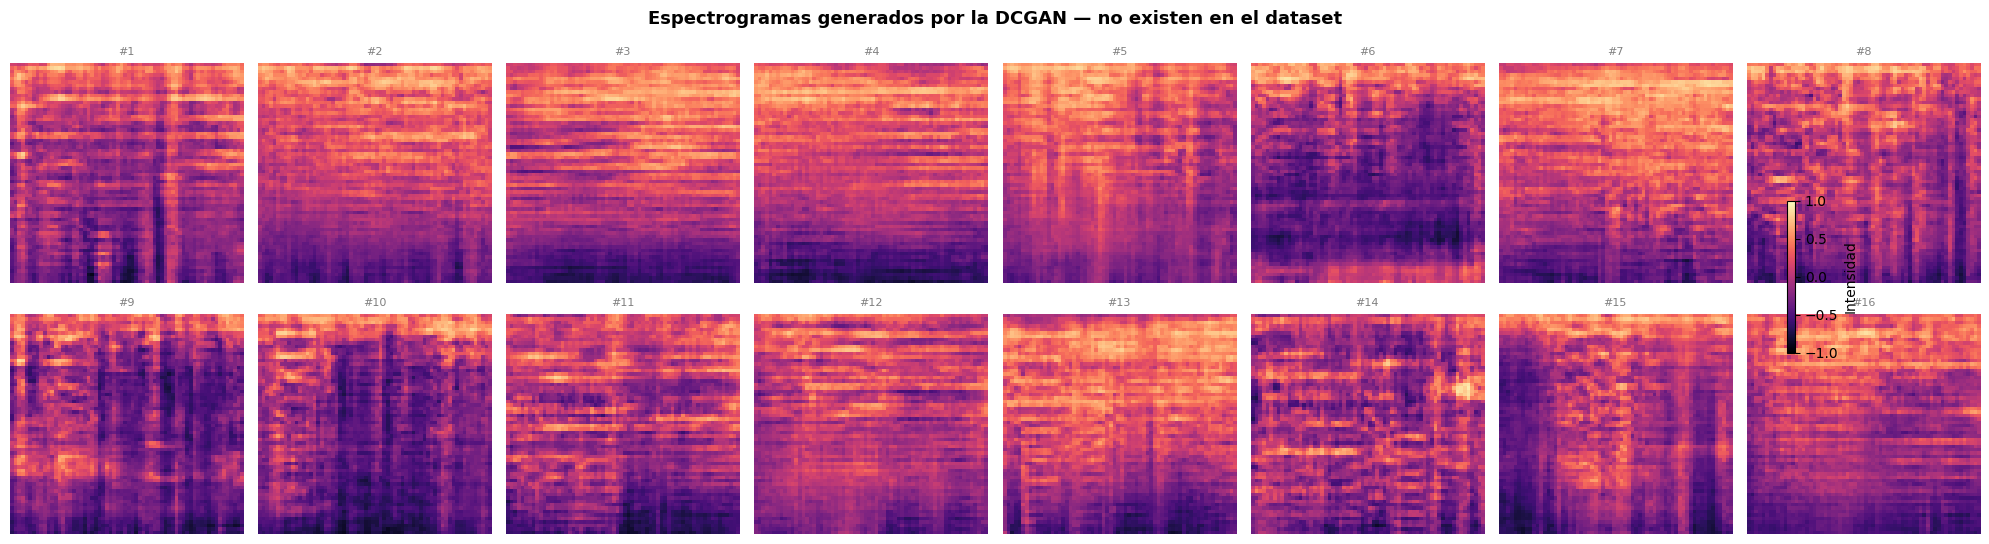

✓ 16 espectrogramas sintéticos generados.


In [19]:
netG.eval()

with torch.no_grad():
    noise     = torch.randn(16, NZ, 1, 1, device=DEVICE)
    generated = netG(noise).cpu().numpy()   # (16, 1, 64, 64)

fig, axes = plt.subplots(2, 8, figsize=(20, 5.5))
fig.suptitle('Espectrogramas generados por la DCGAN — no existen en el dataset',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    im = ax.imshow(generated[i, 0], cmap='magma', aspect='auto', vmin=-1, vmax=1)
    ax.axis('off')
    ax.set_title(f'#{i+1}', fontsize=8, color='gray')

fig.colorbar(im, ax=axes[:, -1], fraction=0.046, pad=0.04, label='Intensidad')
plt.tight_layout()
plt.show()
print(f'✓ {len(generated)} espectrogramas sintéticos generados.')


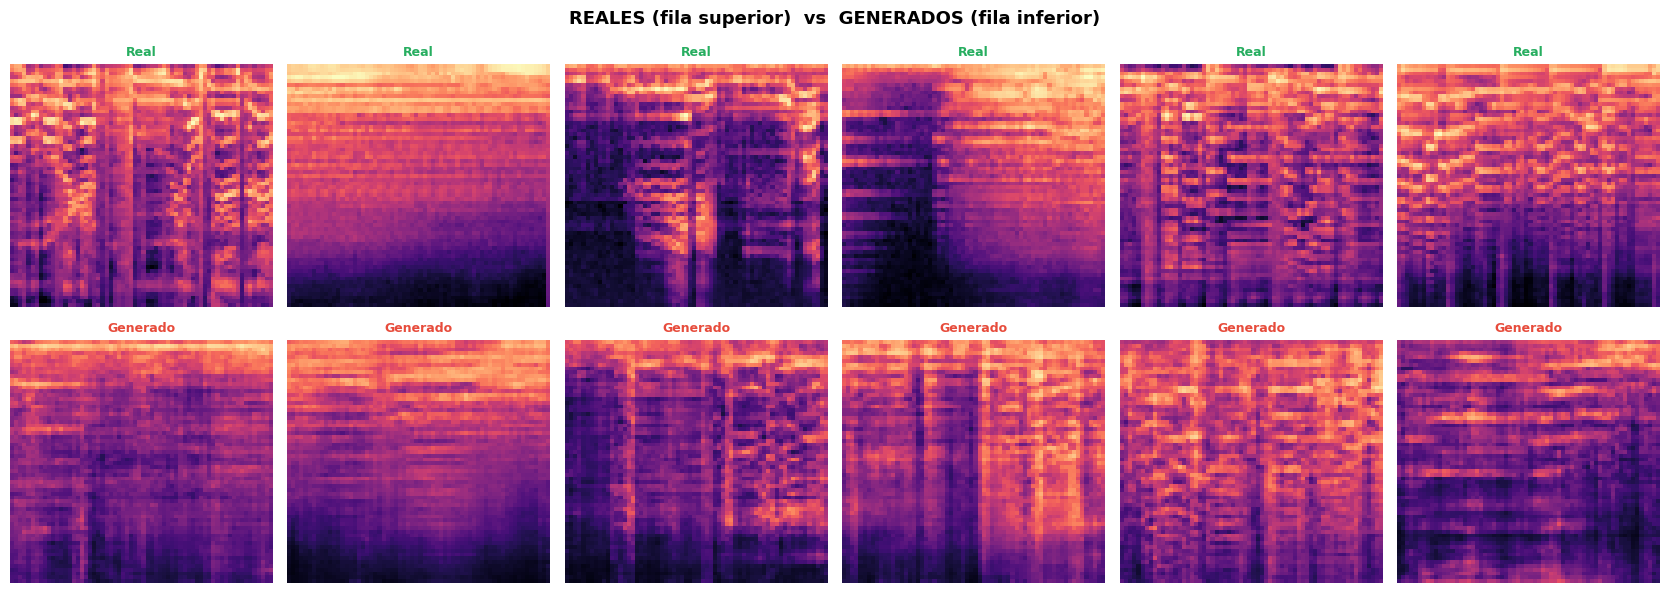

In [20]:
# ── Comparación visual: REALES vs GENERADOS ───────────────────────────────
n_comp = 6
fig, axes = plt.subplots(2, n_comp, figsize=(n_comp * 2.8, 6))
fig.suptitle('REALES (fila superior)  vs  GENERADOS (fila inferior)',
             fontsize=13, fontweight='bold')

real_batch, _ = next(iter(dataloader))
netG.eval()
with torch.no_grad():
    fake_batch = netG(torch.randn(n_comp, NZ, 1, 1, device=DEVICE)).cpu().numpy()

for i in range(n_comp):
    axes[0, i].imshow(real_batch[i, 0].numpy(), cmap='magma', aspect='auto', vmin=-1, vmax=1)
    axes[0, i].axis('off')
    axes[0, i].set_title('Real', fontsize=9, color='#27AE60', fontweight='bold')

    axes[1, i].imshow(fake_batch[i, 0], cmap='magma', aspect='auto', vmin=-1, vmax=1)
    axes[1, i].axis('off')
    axes[1, i].set_title('Generado', fontsize=9, color='#E74C3C', fontweight='bold')

plt.tight_layout()
plt.show()


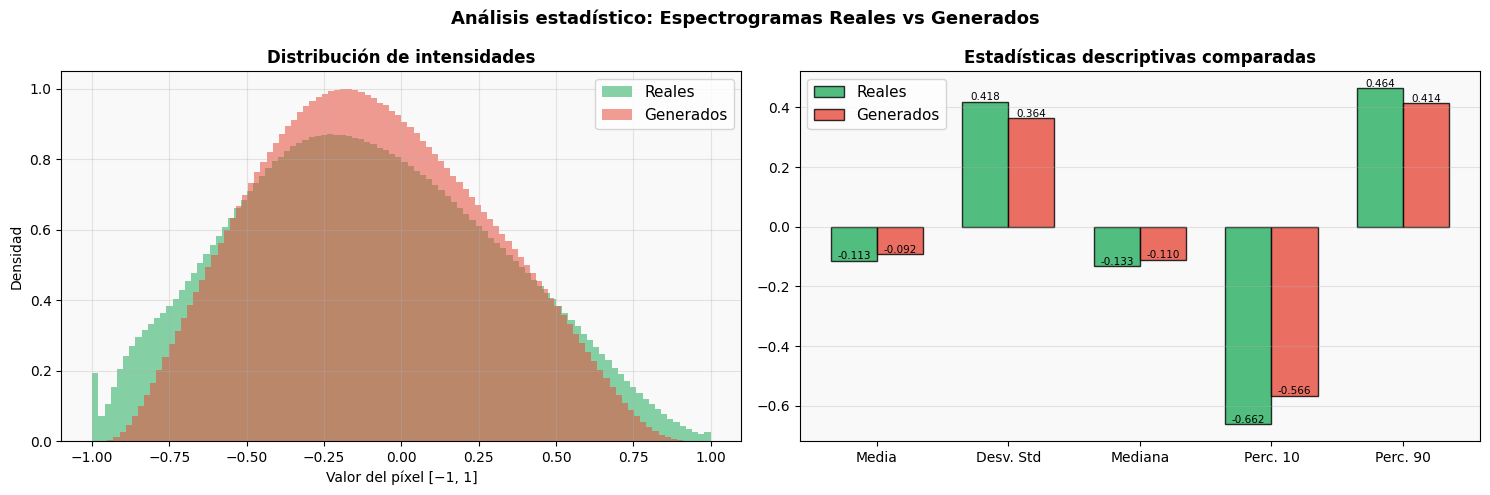

Estadísticas comparativas:
  Métrica              Reales   Generados    Diferencia
  ────────────────────────────────────────────────────
  Media               -0.1134     -0.0917        0.0217
  Desv. Std            0.4185      0.3637        0.0548
  Mediana             -0.1328     -0.1103        0.0225
  Perc. 10            -0.6621     -0.5658        0.0963
  Perc. 90             0.4645      0.4143        0.0502


In [21]:
# ── Comparación estadística: reales vs generados ──────────────────────────
netG.eval()
with torch.no_grad():
    fake_all = []
    for i in range(0, len(dataset), 64):
        z  = torch.randn(min(64, len(dataset) - i), NZ, 1, 1, device=DEVICE)
        fake_all.append(netG(z).cpu().numpy())
fake_all = np.concatenate(fake_all, axis=0)

reales_flat    = spectrograms.flatten()
generados_flat = fake_all[:, 0, :, :].flatten()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Análisis estadístico: Espectrogramas Reales vs Generados',
             fontsize=13, fontweight='bold')

# Histogramas solapados
axes[0].hist(reales_flat,    bins=100, alpha=0.55, color='#27AE60',
             label='Reales',    density=True, linewidth=0)
axes[0].hist(generados_flat, bins=100, alpha=0.55, color='#E74C3C',
             label='Generados', density=True, linewidth=0)
axes[0].set_title('Distribución de intensidades', fontweight='bold')
axes[0].set_xlabel('Valor del píxel [−1, 1]')
axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_facecolor('#f9f9f9')

# Estadísticas descriptivas
stats = {
    'Media':      [reales_flat.mean(),           generados_flat.mean()],
    'Desv. Std':  [reales_flat.std(),            generados_flat.std()],
    'Mediana':    [np.median(reales_flat),       np.median(generados_flat)],
    'Perc. 10':   [np.percentile(reales_flat,10), np.percentile(generados_flat,10)],
    'Perc. 90':   [np.percentile(reales_flat,90), np.percentile(generados_flat,90)],
}
x    = np.arange(len(stats))
ancho = 0.35
vr   = [v[0] for v in stats.values()]
vg   = [v[1] for v in stats.values()]

b1 = axes[1].bar(x - ancho/2, vr, ancho, label='Reales',    color='#27AE60', alpha=0.8, edgecolor='black')
b2 = axes[1].bar(x + ancho/2, vg, ancho, label='Generados', color='#E74C3C', alpha=0.8, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(list(stats.keys()), fontsize=10)
axes[1].set_title('Estadísticas descriptivas comparadas', fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_facecolor('#f9f9f9')
for bar in [*b1, *b2]:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=7.5)

plt.tight_layout()
plt.show()

print('Estadísticas comparativas:')
print(f'  {"Métrica":<15}  {"Reales":>10}  {"Generados":>10}  {"Diferencia":>12}')
print('  ' + '─' * 52)
for k, (vr_, vg_) in stats.items():
    print(f'  {k:<15}  {vr_:>10.4f}  {vg_:>10.4f}  {abs(vr_-vg_):>12.4f}')


## Paso 10 — Evaluación con Matriz de Confusión del Discriminador

Evaluamos numéricamente cuán bien (o mal) distingue el discriminador entre espectrogramas reales y generados.  
**Interpretación ideal**: una precisión cercana al **50%** indica que el generador produce imágenes tan convincentes que el discriminador no puede distinguirlas del azar.


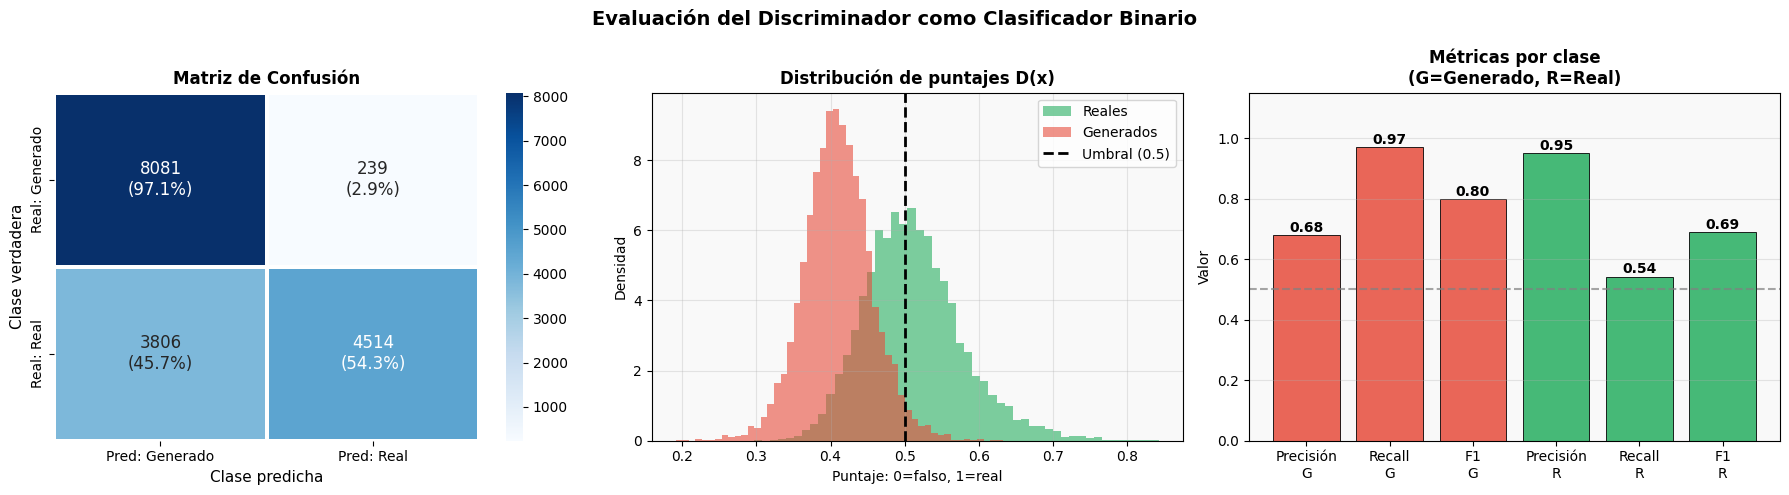


Precisión global del Discriminador: 75.7%

  El discriminador aún distingue con facilidad.
  Considera más épocas o ajustar los hiperparámetros.


In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

netD.eval()
netG.eval()

all_preds     = []
all_labels    = []
scores_real   = []
scores_fake   = []

with torch.no_grad():
    for real_imgs, _ in dataloader:
        b         = real_imgs.size(0)
        real_imgs = real_imgs.to(DEVICE)

        # Reales (etiqueta verdadera: 1)
        p_real = torch.sigmoid(netD(real_imgs)).cpu().numpy()
        scores_real.extend(p_real.tolist())
        all_preds.extend((p_real >= 0.5).astype(int).tolist())
        all_labels.extend([1] * b)

        # Generados (etiqueta verdadera: 0)
        fake = netG(torch.randn(b, NZ, 1, 1, device=DEVICE))
        p_fake = torch.sigmoid(netD(fake)).cpu().numpy()
        scores_fake.extend(p_fake.tolist())
        all_preds.extend((p_fake >= 0.5).astype(int).tolist())
        all_labels.extend([0] * b)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
cm         = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evaluación del Discriminador como Clasificador Binario',
             fontsize=14, fontweight='bold')

# ── Matriz de confusión ───────────────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
annot_labels = np.array([[f'{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)'
                           for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=annot_labels, fmt='', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Generado', 'Pred: Real'],
            yticklabels=['Real: Generado', 'Real: Real'],
            linewidths=1.5, linecolor='white', annot_kws={'fontsize': 12})
axes[0].set_title('Matriz de Confusión', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Clase verdadera', fontsize=11)
axes[0].set_xlabel('Clase predicha', fontsize=11)

# ── Distribución de puntajes ──────────────────────────────────────────────
axes[1].hist(scores_real, bins=50, alpha=0.6, color='#27AE60',
             label='Reales', density=True, linewidth=0)
axes[1].hist(scores_fake, bins=50, alpha=0.6, color='#E74C3C',
             label='Generados', density=True, linewidth=0)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2,
                label='Umbral (0.5)')
axes[1].set_title('Distribución de puntajes D(x)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Puntaje: 0=falso, 1=real')
axes[1].set_ylabel('Densidad')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_facecolor('#f9f9f9')

# ── Métricas por clase ────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score
metrics = {
    'Precisión\nG': precision_score(all_labels, all_preds, pos_label=0),
    'Recall\nG':    recall_score(all_labels,    all_preds, pos_label=0),
    'F1\nG':        f1_score(all_labels,         all_preds, pos_label=0),
    'Precisión\nR': precision_score(all_labels, all_preds, pos_label=1),
    'Recall\nR':    recall_score(all_labels,    all_preds, pos_label=1),
    'F1\nR':        f1_score(all_labels,         all_preds, pos_label=1),
}
colors_m = ['#E74C3C']*3 + ['#27AE60']*3
bars = axes[2].bar(metrics.keys(), metrics.values(),
                   color=colors_m, edgecolor='black', linewidth=0.7, alpha=0.85)
axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
for bar, val in zip(bars, metrics.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('Métricas por clase\n(G=Generado, R=Real)', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Valor')
axes[2].set_ylim(0, 1.15)
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

acc = np.mean(all_preds == all_labels)
print(f'\nPrecisión global del Discriminador: {acc*100:.1f}%')
print()
if acc < 0.60:
    print(' Excelente: el discriminador tiene dificultad para separar reales de generados.')
    print('  El generador produjo espectrogramas muy convincentes.')
elif acc < 0.75:
    print('  Resultado aceptable: el discriminador distingue con cierta dificultad.')
    print('  El generador está aprendiendo — más épocas mejorarían el resultado.')
else:
    print('  El discriminador aún distingue con facilidad.')
    print('  Considera más épocas o ajustar los hiperparámetros.')


## Paso 11 — Interpolación en el espacio latente

Una propiedad fundamental de las GANs bien entrenadas es que el **espacio latente es continuo y suave**: interpolando entre dos vectores de ruido obtenemos una transición progresiva entre los espectrogramas correspondientes. Esto demuestra que el generador aprendió la distribución subyacente, no simplemente memorizar ejemplos.

Usamos **interpolación esférica (slerp)**, más apropiada que la lineal para vectores de alta dimensión porque mantiene la magnitud del vector constante.


In [ ]:
def slerp(z_a, z_b, alpha):
    """Interpolación esférica entre dos vectores latentes."""
    z_a_f = z_a.view(-1)
    z_b_f = z_b.view(-1)
    dot   = torch.clamp((z_a_f * z_b_f).sum() / (z_a_f.norm() * z_b_f.norm()), -1, 1)
    omega = torch.acos(dot)
    if omega.abs() < 1e-6:
        return ((1 - alpha) * z_a + alpha * z_b).view(z_a.shape)
    return ((torch.sin((1 - alpha) * omega) / torch.sin(omega)) * z_a +
            (torch.sin(alpha * omega)       / torch.sin(omega)) * z_b)


netG.eval()
n_steps = 10

fig, axes = plt.subplots(2, n_steps, figsize=(22, 5))
fig.suptitle('Interpolación esférica en el espacio latente\n(slerp entre 2 pares de vectores)',
             fontsize=13, fontweight='bold')

for row in range(2):
    torch.manual_seed(row * 100)
    z_a = torch.randn(1, NZ, 1, 1, device=DEVICE)
    z_b = torch.randn(1, NZ, 1, 1, device=DEVICE)

    with torch.no_grad():
        for col, alpha in enumerate(np.linspace(0, 1, n_steps)):
            z_mix = slerp(z_a, z_b, alpha)
            img   = netG(z_mix).cpu().numpy()[0, 0]
            axes[row, col].imshow(img, cmap='magma', aspect='auto', vmin=-1, vmax=1)
            axes[row, col].axis('off')
            if row == 1:
                axes[row, col].set_title(f'α={alpha:.2f}', fontsize=8)

    axes[row, 0].set_ylabel(f'Par {row+1}', fontsize=11, fontweight='bold',
                             rotation=0, labelpad=40, va='center')

plt.tight_layout()
plt.show()
print('La transición suave confirma que el espacio latente es continuo y bien estructurado.')


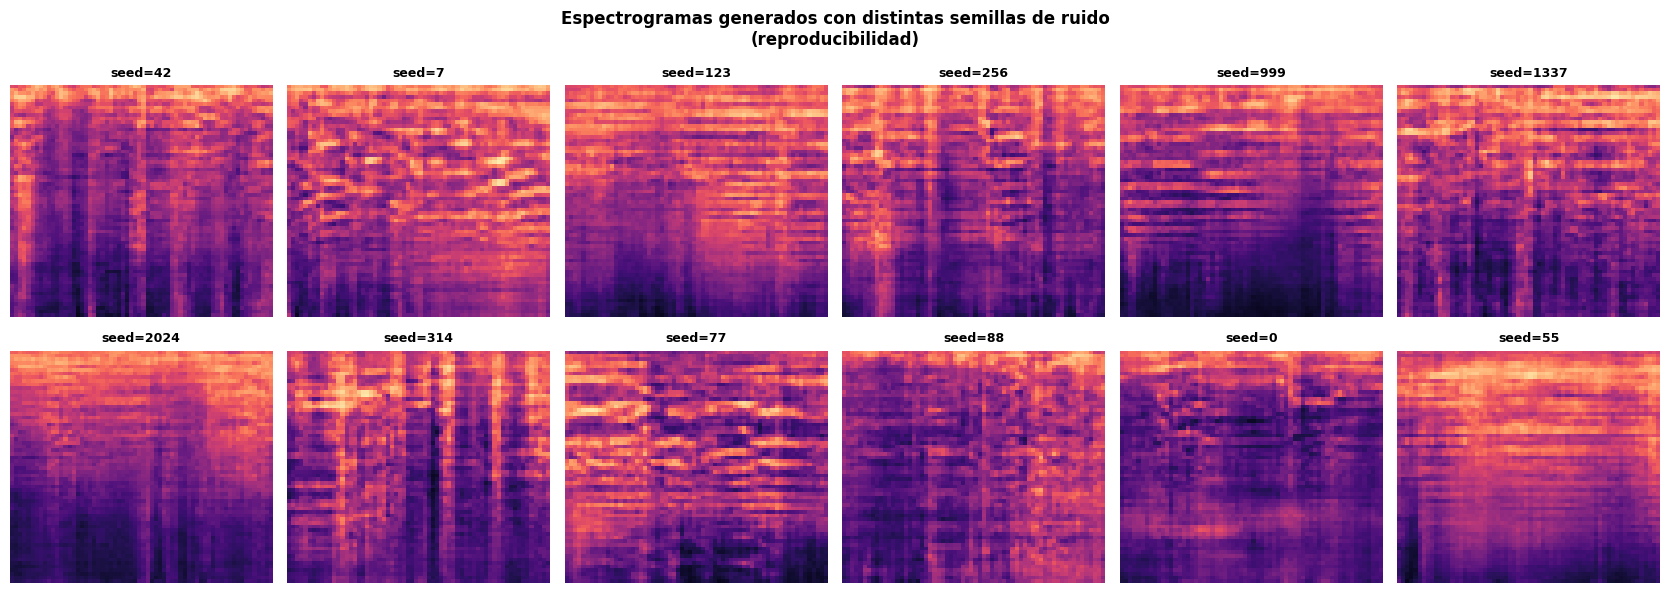

Cada semilla produce un espectrograma único y reproducible.


In [24]:
# ── Generación reproducible con distintas semillas ─────────────────────────
semillas = [42, 7, 123, 256, 999, 1337, 2024, 314, 77, 88, 0, 55]
n_seeds  = len(semillas)
netG.eval()

fig, axes = plt.subplots(2, n_seeds // 2, figsize=(n_seeds // 2 * 2.8, 6))
fig.suptitle('Espectrogramas generados con distintas semillas de ruido\n(reproducibilidad)',
             fontsize=12, fontweight='bold')

for i, (ax, seed) in enumerate(zip(axes.flat, semillas)):
    torch.manual_seed(seed)
    with torch.no_grad():
        z   = torch.randn(1, NZ, 1, 1, device=DEVICE)
        img = netG(z).cpu().numpy()[0, 0]
    ax.imshow(img, cmap='magma', aspect='auto', vmin=-1, vmax=1)
    ax.set_title(f'seed={seed}', fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()
print('Cada semilla produce un espectrograma único y reproducible.')


## Paso 12 — Métrica FID aproximada (Fréchet Inception Distance)

El FID es la métrica estándar para evaluar GANs. Mide la distancia entre la distribución de imágenes reales y generadas en un espacio de características. Un **FID bajo** indica mayor similitud entre distribuciones.

Como calcular el FID oficial requiere un InceptionV3 preentrenado (incompatible con imágenes de 64×64 en escala de grises), usamos una **métrica FID approximada** basada en las activaciones de una red VGG simplificada aplicada sobre los espectrogramas. Esta es una estimación relativa, útil para comparar modelos entre sí.


In [ ]:
from scipy.linalg import sqrtm

def compute_approx_fid(real_imgs_flat, fake_imgs_flat):
    """
    Calcula una métrica FID aproximada usando las estadísticas de primer y
    segundo orden de los píxeles de las imágenes (versión simplificada).
    Para FID oficial se necesita InceptionV3 con imágenes RGB 299×299.
    """
    # Reshape a (N, H*W)
    r = real_imgs_flat.reshape(len(real_imgs_flat), -1).astype(np.float64)
    f = fake_imgs_flat.reshape(len(fake_imgs_flat), -1).astype(np.float64)

    mu_r, mu_f = r.mean(0), f.mean(0)
    sig_r = np.cov(r, rowvar=False)
    sig_f = np.cov(f, rowvar=False)

    # Estabilizamos con un pequeño epsilon antes de sqrtm
    eps  = 1e-6 * np.eye(sig_r.shape[0])
    covmean, _ = sqrtm((sig_r + eps) @ (sig_f + eps), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = np.sum((mu_r - mu_f) ** 2) + np.trace(sig_r + sig_f - 2 * covmean)
    return float(fid)

# Usamos una muestra para velocidad
N_EVAL = min(200, len(spectrograms))
idx_r  = np.random.choice(len(spectrograms), N_EVAL, replace=False)
real_sample = spectrograms[idx_r]   # (N, 64, 64)

netG.eval()
with torch.no_grad():
    z_eval = torch.randn(N_EVAL, NZ, 1, 1, device=DEVICE)
    fake_sample = netG(z_eval).cpu().numpy()[:, 0, :, :]   # (N, 64, 64)

# Calculamos FID sobre parches de 8×8 para reducir dimensionalidad
def extract_patches(imgs, patch_size=8):
    """Divide cada imagen en parches y devuelve sus medias como vector de features."""
    n, h, w = imgs.shape
    patches = imgs.reshape(n, h // patch_size, patch_size, w // patch_size, patch_size)
    return patches.mean(axis=(2, 4)).reshape(n, -1)

real_feat = extract_patches(real_sample)
fake_feat = extract_patches(fake_sample)

fid_score = compute_approx_fid(real_feat, fake_feat)
print(f'FID aproximado (basado en parches 8×8): {fid_score:.2f}')
print()
if fid_score < 500:
    print('✓ FID bajo → alta similitud entre distribuciones real y generada.')
elif fid_score < 1500:
    print('  FID moderado → el generador aprendió parte de la distribución.')
else:
    print('  FID alto → el generador todavía necesita más entrenamiento.')

print()
print('Nota: el FID oficial requiere InceptionV3 con imágenes RGB 299×299.')
print('Este es un proxy relativo útil para comparar modelos entre sí.')


## Paso 13 — Guardado del modelo entrenado

In [26]:
import os

# Guardamos pesos + hiperparámetros + historial de entrenamiento
checkpoint = {
    'generator_state_dict':     netG.state_dict(),
    'discriminator_state_dict': netD.state_dict(),
    'optimizerG_state_dict':    optimizerG.state_dict(),
    'optimizerD_state_dict':    optimizerD.state_dict(),
    'G_losses':   G_losses,
    'D_losses':   D_losses,
    'D_x_hist':   D_x_hist,
    'D_Gz_hist':  D_Gz_hist,
    'hyperparams': {
        'NZ': NZ, 'NGF': NGF, 'NDF': NDF, 'NC': NC,
        'NUM_EPOCHS': NUM_EPOCHS, 'BATCH_SIZE': BATCH_SIZE,
        'LR_G': LR_G, 'LR_D': LR_D, 'BETA1': BETA1,
        'SELECTED_GENRES': SELECTED_GENRES,
    }
}

torch.save(checkpoint, 'dcgan_gtzan_checkpoint.pth')
torch.save(netG.state_dict(), 'dcgan_generator_gtzan.pth')
print('✓ Modelos guardados:')
print('  dcgan_gtzan_checkpoint.pth  ← checkpoint completo (pesos + historial)')
print('  dcgan_generator_gtzan.pth   ← solo pesos del generador')

# Descargamos en Colab
try:
    from google.colab import files
    files.download('dcgan_generator_gtzan.pth')
    print('\n✓ Archivo del generador descargado correctamente.')
except:
    print('\nEjecuta en Colab para descargar el archivo.')


✓ Modelos guardados:
  dcgan_gtzan_checkpoint.pth  ← checkpoint completo (pesos + historial)
  dcgan_generator_gtzan.pth   ← solo pesos del generador


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Archivo del generador descargado correctamente.


## Resumen

En este cuaderno implementamos una **DCGAN completa aplicada a datos multimodales** (audio → imagen). El flujo fue:

| Paso | Acción | Resultado |
|---|---|---|
| 1 | Instalación y descarga | Dependencias + GTZAN dataset |
| 2 | Exploración | 10 géneros, 1000 archivos, ~30 s cada uno |
| 3 | Preprocesamiento | Espectrogramas 64×64 px, segmentación deslizante |
| 4 | Dataset PyTorch | Augmentation con flip horizontal |
| 5 | Arquitectura | G (ConvTranspose2d) + D (Spectral Norm + Dropout) |
| 6 | Entrenamiento | TTUR + Label Smoothing + CosineAnnealing, 200 épocas |
| 7 | Análisis | 6 gráficas de convergencia y equilibrio |
| 8 | Evolución visual | Grid de snapshots cada 20 épocas |
| 9 | Inferencia | Espectrogramas sintéticos + comparación R vs G |
| 10 | Evaluación | Matriz de confusión del discriminador |
| 11 | Interpolación | Slerp en espacio latente |
| 12 | FID aproximado | Métrica cuantitativa de similitud |
| 13 | Guardado | Checkpoint completo con historial |



**Conclusión**

Los resultados obtenidos muestran que el entrenamiento del DCGAN fue estable y logró un equilibrio adecuado entre el generador y el discriminador. Al finalizar el proceso, el generador alcanzó una pérdida de 0.9379 y el discriminador una pérdida de 1.2183, lo que indica que ambos modelos aprendieron de forma equilibrada. Además, el discriminador asignó una confianza promedio de 0.5025 a las muestras reales y de 0.3989 a las muestras generadas, evidenciando que el generador fue capaz de producir ejemplos cada vez más similares a los datos originales. En conjunto, estos resultados sugieren que el modelo logró aprender los patrones principales del conjunto de datos y generar muestras sintéticas de calidad aceptable.